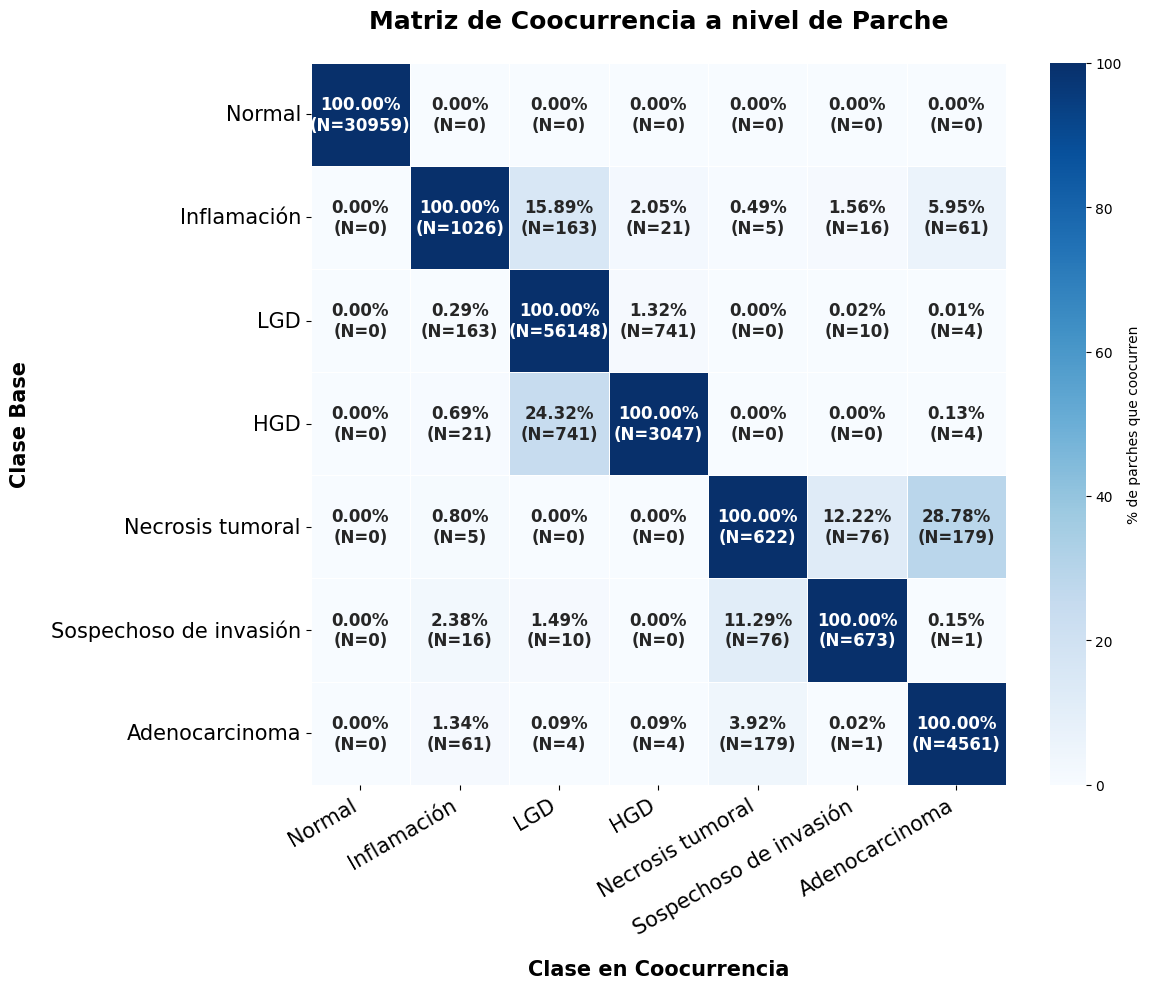

In [ ]:
import os
import itertools
from collections import Counter
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# CONFIGURACIÓN DE CLASES Y TRADUCCIÓN DE NOMBRES
# =========================================================

ROOT    = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
H5_FOLDER = ROOT / 'h5_multilabel'
STATISTICS_FOLDER = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Statistics')
H5_FILES = list(Path(H5_FOLDER).glob("*.h5"))


CLASS_NAMES = [
    "normal",
    "lowgrade_dysplasia",
    "inflammation",
    "highgrade_dysplasia",
    "tumor_necrosis",
    "suspicious_for_invasion",
    "adenocarcinoma",
]

MAPEO_NOMBRES = {
    "normal": "Normal",
    "lowgrade_dysplasia": "LGD",
    "inflammation": "Inflamación",
    "highgrade_dysplasia": "HGD",
    "tumor_necrosis": "Necrosis tumoral",
    "suspicious_for_invasion": "Sospechoso de invasión",
    "adenocarcinoma": "Adenocarcinoma"
}

CLASES_ORDENADAS = [
    'Normal',
    'Inflamación',
    'LGD',
    'HGD',
    'Necrosis tumoral',
    'Sospechoso de invasión',  
    'Adenocarcinoma'
]

# =========================================================
# ANÁLISIS MULTILABEL ORIGINAL
# =========================================================

rows = []
global_counter = Counter()
global_wsi_tracker = {}

# Diccionario para registrar el total absoluto de parches por clase (para la diagonal)
totales_absolutos_clase = Counter()

for h5_path in H5_FILES:
    with h5py.File(h5_path, "r") as f:
        if "labels" not in f:
            continue
            
        labels = f["labels"][:]

        # Robustez: Corregir dimensiones si vienen invertidas (7, N)
        if labels.shape[0] == len(CLASS_NAMES) and labels.shape[1] != len(CLASS_NAMES):
            labels = labels.T

        # Contabilizar el total de parches de cada clase en este archivo antes del filtro multilabel
        conteo_archivo = labels.sum(axis=0)
        for i, total_clase in enumerate(conteo_archivo):
            clase_traducida = MAPEO_NOMBRES[CLASS_NAMES[i]]
            totales_absolutos_clase[clase_traducida] += total_clase

        # Suma por patch
        label_counts = labels.sum(axis=1)

        # Patches multilabel
        multilabel_mask = label_counts > 1
        multilabel_indices = np.where(multilabel_mask)[0]

        # Si no hay multilabel, skip
        if len(multilabel_indices) == 0:
            continue

        # Contar combinaciones dentro de esta WSI
        counter = Counter()

        for idx in multilabel_indices:
            active_classes = np.where(labels[idx] > 0)[0]

            # Traducimos los nombres en caliente para homogeneizar CSVs y Gráficos
            combo = tuple(
                MAPEO_NOMBRES[CLASS_NAMES[i]]
                for i in active_classes
            )

            counter[combo] += 1
            global_counter[combo] += 1
            
            if combo not in global_wsi_tracker:
                global_wsi_tracker[combo] = set()
            global_wsi_tracker[combo].add(h5_path.name)

        # Guardar resumen WSI
        rows.append({
            "wsi": h5_path.name,
            "total_patches": labels.shape[0],
            "multilabel_patches": len(multilabel_indices),
            "multilabel_percentage (%)": round(
                (len(multilabel_indices) / labels.shape[0]) * 100,
                2
            ),
            "unique_multilabel_combinations": len(counter),
            "combinations_found": " || ".join([
                f"{' + '.join(combo)} ({count})"
                for combo, count in counter.items()
            ])
        })

multilabel_df = pd.DataFrame(rows)
multilabel_df = multilabel_df.sort_values(by="multilabel_patches", ascending=False)

combo_rows = []
for combo, count in global_counter.items():
    num_wsi = len(global_wsi_tracker.get(combo, set()))
    if num_wsi == 0 and count > 0:
        num_wsi = 1
    
    combo_rows.append({
        "combination": " + ".join(combo),
        "num_patches": count,
        "num_WSI": num_wsi,
        "num_classes": len(combo)
    })

combo_df = pd.DataFrame(combo_rows)
combo_df = combo_df.sort_values(by="num_patches", ascending=False)


# =========================================================
# GENERACIÓN DE LA MATRIZ DE COOCURRENCIA
# =========================================================

# Inicializar la matriz vacía con el orden solicitado
matriz_bruta = pd.DataFrame(0, index=CLASES_ORDENADAS, columns=CLASES_ORDENADAS)

# Llenar las coocurrencias
for combo, count in global_counter.items():
    for c1, c2 in itertools.combinations(combo, 2):
        matriz_bruta.loc[c1, c2] += count
        matriz_bruta.loc[c2, c1] += count  # Simetría inicial en valores absolutos

# Llenar la diagonal principal con los totales absolutos que guardamos en el bucle
for clase in CLASES_ORDENADAS:
    matriz_bruta.loc[clase, clase] = totales_absolutos_clase[clase]

# Calcular la matriz de porcentajes (normalizado por fila / Clase Base)
totales_clase_base = pd.Series(np.diag(matriz_bruta), index=matriz_bruta.index)
matriz_porcentual = matriz_bruta.div(totales_clase_base, axis=0) * 100
matriz_porcentual = matriz_porcentual.fillna(0)  # Evita errores si una clase tiene 0 parches totales

# Construir las etiquetas de texto personalizadas de doble línea
matriz_texto = pd.DataFrame("", index=CLASES_ORDENADAS, columns=CLASES_ORDENADAS)
for fila in CLASES_ORDENADAS:
    for columna in CLASES_ORDENADAS:
        pct = matriz_porcentual.loc[fila, columna]
        n_parches = int(matriz_bruta.loc[fila, columna])
        # Mantiene los dos decimales solicitados
        matriz_texto.loc[fila, columna] = f"{pct:.2f}%\n(N={n_parches})"

# Configurar y dIbujar el Mapa de Calor
plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz_porcentual,
    annot=matriz_texto,
    fmt="",
    cmap="Blues",  
    linewidths=0.5,
    annot_kws={"size": 12, "weight": "semibold"},
    cbar_kws={"label": "% de parches que coocurren"},
    vmin=0, vmax=100
)

plt.title(
    "Matriz de Coocurrencia a nivel de Parche", 
    fontsize=18, fontweight="bold", pad=25
)
plt.xlabel("Clase en Coocurrencia", fontsize=15, fontweight="bold", labelpad=15)
plt.ylabel("Clase Base", fontsize=15, fontweight="bold", labelpad=15)

plt.xticks(rotation=30, ha="right", fontsize=15)
plt.yticks(rotation=0, fontsize=15)
plt.tight_layout()

# Mostrar el gráfico en pantalla
plt.show()

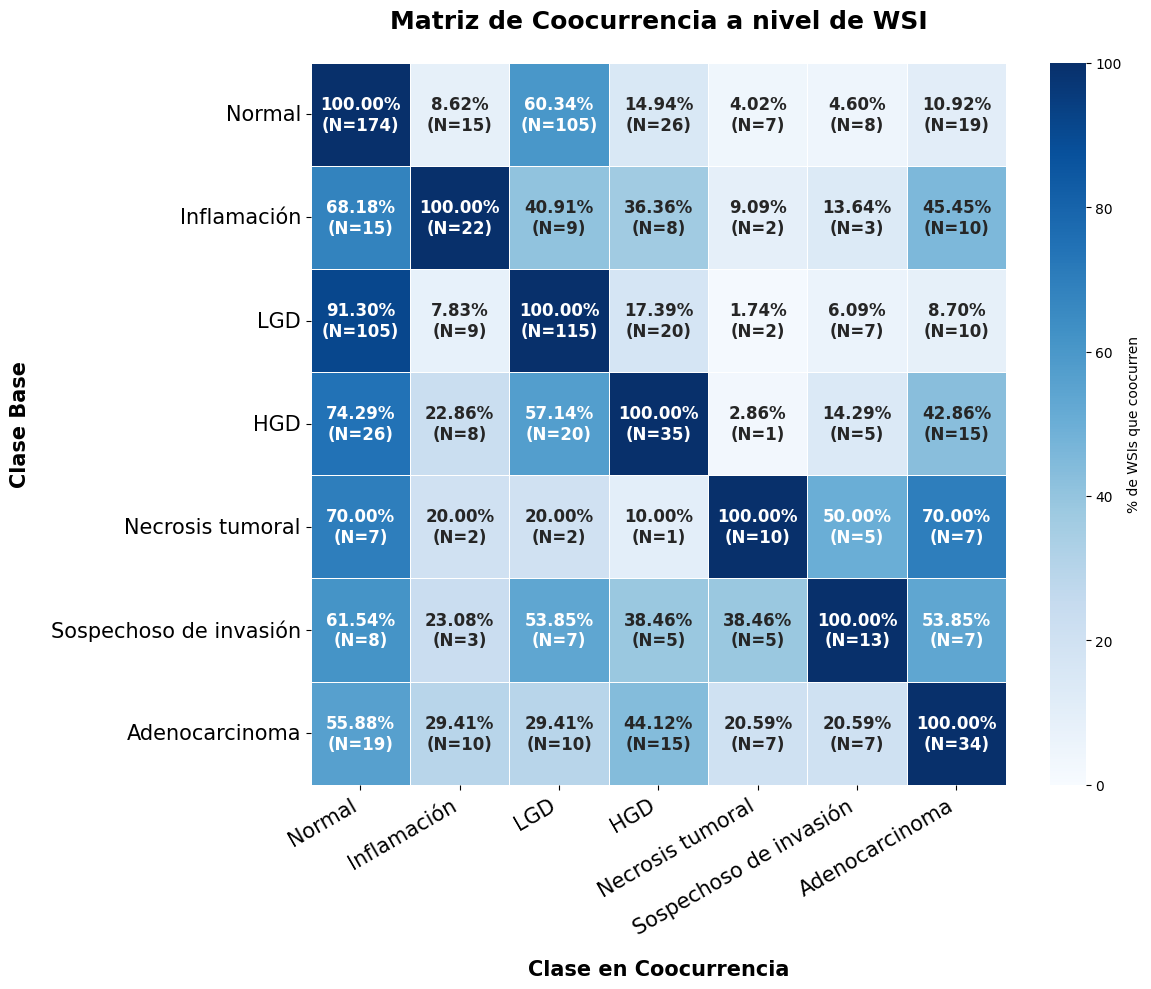

In [ ]:
import os
import itertools
from collections import Counter
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# CONFIGURACIÓN DE CLASES Y TRADUCCIÓN DE NOMBRES
# =========================================================

ROOT    = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
H5_FOLDER = ROOT / 'h5_multilabel'
STATISTICS_FOLDER = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Statistics')
H5_FILES = list(Path(H5_FOLDER).glob("*.h5"))


CLASS_NAMES = [
    "normal",
    "lowgrade_dysplasia",
    "inflammation",
    "highgrade_dysplasia",
    "tumor_necrosis",
    "suspicious_for_invasion",
    "adenocarcinoma",
]

MAPEO_NOMBRES = {
    "normal": "Normal",
    "lowgrade_dysplasia": "LGD",
    "inflammation": "Inflamación",
    "highgrade_dysplasia": "HGD",
    "tumor_necrosis": "Necrosis tumoral",
    "suspicious_for_invasion": "Sospechoso de invasión",
    "adenocarcinoma": "Adenocarcinoma"
}

CLASES_ORDENADAS = [
    'Normal',
    'Inflamación',
    'LGD',
    'HGD',
    'Necrosis tumoral',
    'Sospechoso de invasión',  
    'Adenocarcinoma'
]

# =========================================================
# ANÁLISIS MULTILABEL ORIGINAL
# =========================================================

rows = []
global_counter = Counter()
global_wsi_tracker = {}

# Diccionario para registrar el total absoluto de parches por clase (opcional/guardado por compatibilidad)
totales_absolutos_clase = Counter()

# Inicializar la matriz vacía a nivel de WSI con el orden solicitado
matriz_bruta = pd.DataFrame(0, index=CLASES_ORDENADAS, columns=CLASES_ORDENADAS)

for h5_path in H5_FILES:
    with h5py.File(h5_path, "r") as f:
        if "labels" not in f:
            continue
            
        labels = f["labels"][:]

        if labels.shape[0] == len(CLASS_NAMES) and labels.shape[1] != len(CLASS_NAMES):
            labels = labels.T

        # Contabilizar el total de parches de cada clase en este archivo
        conteo_archivo = labels.sum(axis=0)
        
        # Identificar qué clases están presentes en este archivo WSI (tienen al menos 1 parche)
        clases_presentes_wsi = []
        for i, total_clase in enumerate(conteo_archivo):
            clase_traducida = MAPEO_NOMBRES[CLASS_NAMES[i]]
            totales_absolutos_clase[clase_traducida] += total_clase
            if total_clase > 0:
                clases_presentes_wsi.append(clase_traducida)
        
        # Llenar la matriz bruta contando archivos (WSIs) en lugar de parches
        # Diagonal: Cada clase presente suma 1 archivo H5 detectado
        for clase in clases_presentes_wsi:
            matriz_bruta.loc[clase, clase] += 1
            
        # Fuera de la diagonal: Combinaciones de clases que coexisten en este mismo archivo H5
        for c1, c2 in itertools.combinations(clases_presentes_wsi, 2):
            matriz_bruta.loc[c1, c2] += 1
            matriz_bruta.loc[c2, c1] += 1

        label_counts = labels.sum(axis=1)
        multilabel_mask = label_counts > 1
        multilabel_indices = np.where(multilabel_mask)[0]

        if len(multilabel_indices) == 0:
            continue

        counter = Counter()
        for idx in multilabel_indices:
            active_classes = np.where(labels[idx] > 0)[0]
            combo = tuple(MAPEO_NOMBRES[CLASS_NAMES[i]] for i in active_classes)

            counter[combo] += 1
            global_counter[combo] += 1
            
            if combo not in global_wsi_tracker:
                global_wsi_tracker[combo] = set()
            global_wsi_tracker[combo].add(h5_path.name)

        rows.append({
            "wsi": h5_path.name,
            "total_patches": labels.shape[0],
            "multilabel_patches": len(multilabel_indices),
            "multilabel_percentage (%)": round((len(multilabel_indices) / labels.shape[0]) * 100, 2),
            "unique_multilabel_combinations": len(counter),
            "combinations_found": " || ".join([f"{' + '.join(combo)} ({count})" for combo, count in counter.items()])
        })

multilabel_df = pd.DataFrame(rows)
if not multilabel_df.empty:
    multilabel_df = multilabel_df.sort_values(by="multilabel_patches", ascending=False)

combo_rows = []
for combo, count in global_counter.items():
    num_wsi = len(global_wsi_tracker.get(combo, set()))
    if num_wsi == 0 and count > 0:
        num_wsi = 1
    combo_rows.append({
        "combination": " + ".join(combo),
        "num_patches": count,
        "num_WSI": num_wsi,
        "num_classes": len(combo)
    })

combo_df = pd.DataFrame(combo_rows)
if not combo_df.empty:
    combo_df = combo_df.sort_values(by="num_patches", ascending=False)


# =========================================================
# PROCESAMIENTO Y DIBUJO DEL HEATMAP A NIVEL WSI
# =========================================================

# Calcular la matriz de porcentajes
totales_clase_base = pd.Series(np.diag(matriz_bruta), index=matriz_bruta.index)
matriz_porcentual = matriz_bruta.div(totales_clase_base, axis=0) * 100
matriz_porcentual = matriz_porcentual.fillna(0)  # Protege de divisiones por cero si una clase no aparece nunca

# Construir las etiquetas de texto con formato de dos líneas
matriz_texto = pd.DataFrame("", index=CLASES_ORDENADAS, columns=CLASES_ORDENADAS)
for fila in CLASES_ORDENADAS:
    for columna in CLASES_ORDENADAS:
        pct = matriz_porcentual.loc[fila, columna]
        n_wsis = int(matriz_bruta.loc[fila, columna])
        matriz_texto.loc[fila, columna] = f"{pct:.2f}%\n(N={n_wsis})"

# Configurar y dibujar el Mapa de Calor
plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz_porcentual,
    annot=matriz_texto,
    fmt="",
    cmap="Blues",  
    linewidths=0.5,
    annot_kws={"size": 12, "weight": "semibold"},
    cbar_kws={"label": "% de WSIs que coocurren"},
    vmin=0, vmax=100
)

plt.title(
    "Matriz de Coocurrencia a nivel de WSI", 
    fontsize=18, fontweight="bold", pad=25
)
plt.xlabel("Clase en Coocurrencia", fontsize=15, fontweight="bold", labelpad=15)
plt.ylabel("Clase Base", fontsize=15, fontweight="bold", labelpad=15)

plt.xticks(rotation=30, ha="right", fontsize=15)
plt.yticks(rotation=0, fontsize=15)
plt.tight_layout()

# Mostrar el gráfico final
plt.show()

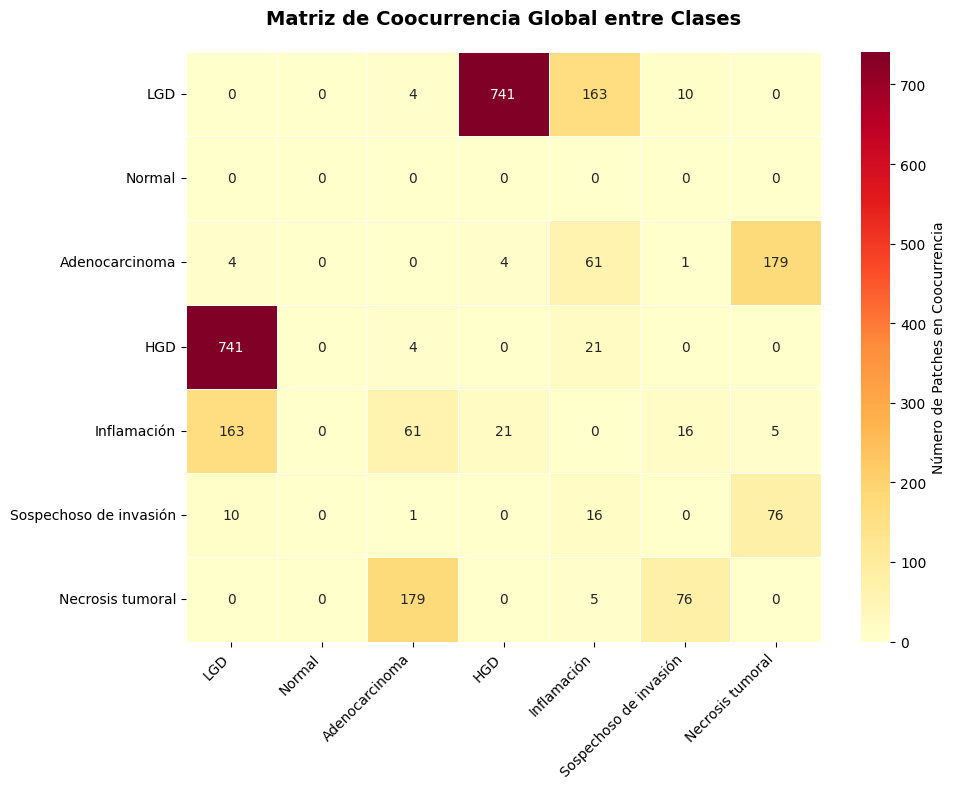

In [ ]:
import itertools
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Definir la lista oficial de clases con los nuevos nombres y en el orden deseado
clases_nuevas = [
    'LGD', 
    'Normal', 
    'Adenocarcinoma', 
    'HGD', 
    'Inflamación', 
    'Sospechoso de invasión', 
    'Necrosis tumoral'
]

# Diccionario de mapeo de nombres antiguos a nombres nuevos
MAPEO_NOMBRES = {
    "normal": "Normal",
    "lowgrade_dysplasia": "LGD",
    "inflammation": "Inflamación",
    "highgrade_dysplasia": "HGD",
    "tumor_necrosis": "Necrosis tumoral",
    "suspicious_for_invasion": "Sospechoso de invasión",
    "adenocarcinoma": "Adenocarcinoma"
}

# 2. Datos extraídos
datos_parches = {
    "lowgrade_dysplasia + highgrade_dysplasia": 741,
    "tumor_necrosis + adenocarcinoma": 176,
    "lowgrade_dysplasia + inflammation": 163,
    "tumor_necrosis + suspicious_for_invasion": 76,
    "inflammation + adenocarcinoma": 58,
    "inflammation + highgrade_dysplasia": 21,
    "inflammation + suspicious_for_invasion": 16,
    "lowgrade_dysplasia + suspicious_for_invasion": 10,
    "highgrade_dysplasia + adenocarcinoma": 4,
    "lowgrade_dysplasia + adenocarcinoma": 4,
    "inflammation + tumor_necrosis + adenocarcinoma": 3,
    "inflammation + tumor_necrosis": 2,
    "suspicious_for_invasion + adenocarcinoma": 1,
}

# Inicializar la matriz de coocurrencia vacía usando las NUEVAS clases
df_matriz = pd.DataFrame(0, index=clases_nuevas, columns=clases_nuevas)

# Procesar los datos traduciendo los nombres sobre la marcha
for combinacion, conteo in datos_parches.items():
    # Separamos las clases originales, limpiamos espacios y las traducimos al nuevo formato
    clases_en_comb = []
    for c in combinacion.split("+"):
        nombre_original = c.strip()
        if nombre_original in MAPEO_NOMBRES:
            clases_en_comb.append(MAPEO_NOMBRES[nombre_original])

    # Generar todas las combinaciones posibles de pares (2 a 2) con los nuevos nombres
    for c1, c2 in itertools.combinations(clases_en_comb, 2):
        if c1 in clases_nuevas and c2 in clases_nuevas:
            df_matriz.loc[c1, c2] += conteo
            df_matriz.loc[c2, c1] += conteo  # La matriz sigue siendo simétrica

# Configurar y dibujar el Mapa de Calor
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_matriz,
    annot=True,
    fmt="g",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Número de Patches en Coocurrencia"},
)

plt.title(
    "Matriz de Coocurrencia Global entre Clases",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Mostrar la figura en pantalla
plt.show()

In [ ]:
from pathlib import Path
import json
import os
import numpy as np
from tabulate import tabulate

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Metrics_multilabel')

PATH_ASL  = ROOT / 'global_report_strategy_None_ASL.json'
PATH_NONE = ROOT / 'global_report_strategy_None_None.json'
PATH_PW   = ROOT / 'global_report_strategy_None_PW.json'
PATH_WS   = ROOT / 'global_report_strategy_WS_None.json'

def load_json(path, name):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error leyendo el archivo {name}: {e}")
        return None

# Intentar cargar todos los datos
data_ASL = load_json(PATH_ASL, "None_ASL")
data_None = load_json(PATH_NONE, "None_None")
data_PW = load_json(PATH_PW, "None_PW")
data_WS = load_json(PATH_WS, "WS_None")

# Validar que todos los archivos se hayan leído correctamente
if not all([data_ASL, data_None, data_PW, data_WS]):
    print("\nEl script se detuvo porque falta configurar o cargar uno o más archivos JSON.")
    exit()

# Agrupación de los diccionarios cargados
methods = {
    "None_ASL": data_ASL,
    "None_None": data_None,
    "None_PW": data_PW,
    "WS_None": data_WS
}

# Mapeo de métricas
metrics_mapping = {
    "F1-Score (Default 0.5)": ("default_0.5", "f1_score"),
    "F1-Score (Optimized)": ("optimized", "f1_score"),
    "PR-AUC": ("independent", "PR-AUC"),
    "ROC-AUC": ("independent", "ROC-AUC"),
    "Umbrales Optimizados (Best Threshold)": ("optimized", "best_threshold")
}

classes = list(data_ASL.keys())

def calculate_macro(method_data, strategy, metric_name):
    """Calcula el promedio macro y propaga correctamente la desviación estándar."""
    means = []
    stds = []
    for c in classes:
        means.append(method_data[c][strategy][metric_name]["mean"])
        stds.append(method_data[c][strategy][metric_name]["std"])
    
    macro_mean = np.mean(means)
    # Propagación de errores para una media: sqrt(sum(std^2)) / N
    macro_std = np.sqrt(np.sum(np.square(stds))) / len(classes)
    return macro_mean, macro_std

# Bucle principal para generar las tres tablas comparativas
for label, (strat, dict_key) in metrics_mapping.items():
    print(f"\n" + "="*65)
    print(f" COMPARATIVA PARA LA MÉTRICA: {label}")
    print("="*65)
    
    table_data = []
    
    # Filas por cada clase/lesión
    for c in classes:
        row = [c]
        for m_name, m_data in methods.items():
            val_mean = m_data[c][strat][dict_key]["mean"]
            val_std = m_data[c][strat][dict_key]["std"]
            row.append(f"{val_mean:.4f} ± {val_std:.4f}")
        table_data.append(row)
    
    # Línea de separación visual para el promedio general
    table_data.append(["-"*25] + ["-"*18]*len(methods))
    
    # Fila final con el cálculo Macro
    macro_row = ["MACRO AVERAGE"]
    for m_name, m_data in methods.items():
        m_mean, m_std = calculate_macro(m_data, strat, dict_key)
        macro_row.append(f"{m_mean:.4f} ± {m_std:.4f}")
    table_data.append(macro_row)
    
    # Cabeceras de la tabla
    headers = ["Clase / Lesión"] + list(methods.keys())
    print(tabulate(table_data, headers=headers, tablefmt="grid"))


 COMPARATIVA PARA LA MÉTRICA: F1-Score (Default 0.5)
+---------------------------+--------------------+--------------------+--------------------+--------------------+
| Clase / Lesión            | None_ASL           | None_None          | None_PW            | WS_None            |
+===========================+====================+====================+====================+====================+
| normal                    | 0.7069 ± 0.0750    | 0.7923 ± 0.0417    | 0.7879 ± 0.0450    | 0.7572 ± 0.0351    |
+---------------------------+--------------------+--------------------+--------------------+--------------------+
| lowgrade_dysplasia        | 0.8102 ± 0.0761    | 0.8744 ± 0.0352    | 0.8699 ± 0.0349    | 0.8414 ± 0.0349    |
+---------------------------+--------------------+--------------------+--------------------+--------------------+
| inflammation              | 0.1635 ± 0.0612    | 0.0450 ± 0.0380    | 0.1578 ± 0.0570    | 0.1083 ± 0.0481    |
+---------------------------+-----

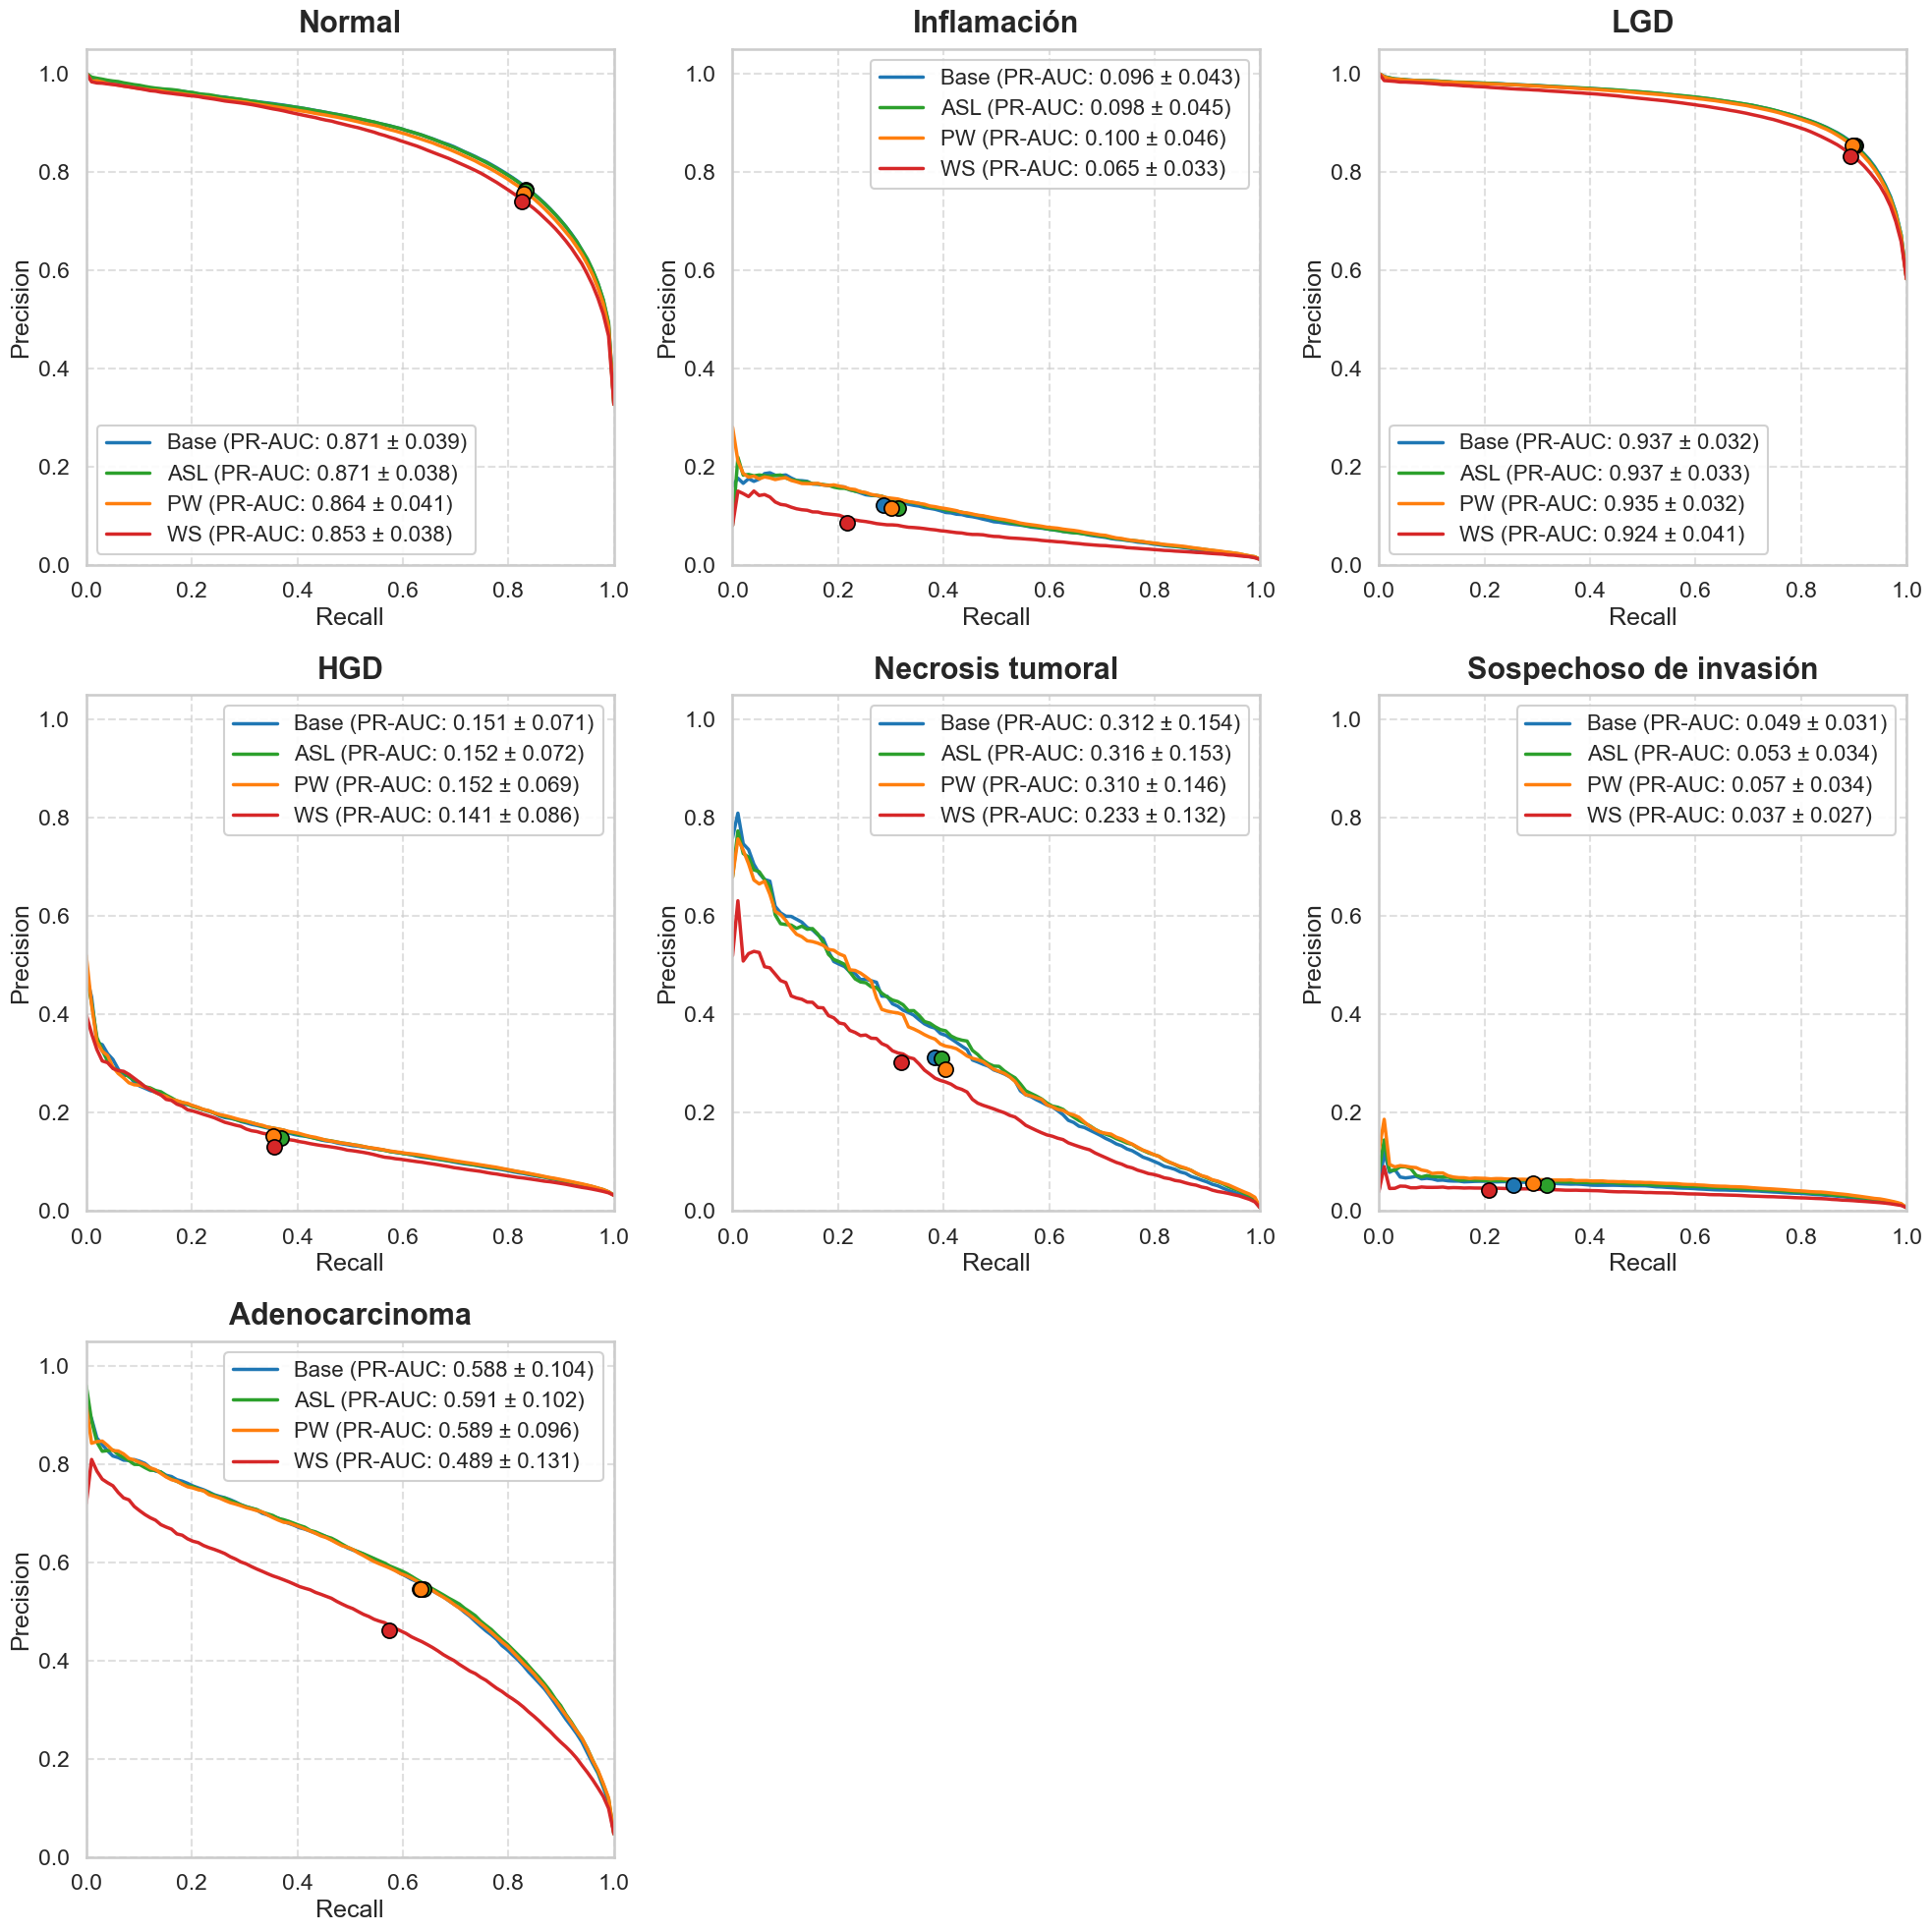

In [ ]:
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# ==========================================
# CONFIGURACIÓN DE PARÁMETROS
# ==========================================
DATA_DIR = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output')
DATA_DIR_2 = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Metrics_multilabel')
SEEDS = [22, 32, 42, 52, 62] 
FOLDS = [1, 2, 3, 4, 5]

METHODS = {
    'None_None': 'Base',
    'None_ASL': 'ASL',
    'None_PW': 'PW',
    'WS_None': 'WS'
}

# Lista ordenada
CLASSES = [
    'normal', 
    'inflammation', 
    'lowgrade_dysplasia', 
    'highgrade_dysplasia',
    'tumor_necrosis', 
    'suspicious_for_invasion', 
    'adenocarcinoma'
]

# Diccionario de mapeo para los títulos en español
MAPEO_NOMBRES = {
    "normal": "Normal",
    "inflammation": "Inflamación",
    "lowgrade_dysplasia": "LGD",
    "highgrade_dysplasia": "HGD",
    "tumor_necrosis": "Necrosis tumoral",
    "suspicious_for_invasion": "Sospechoso de invasión",
    "adenocarcinoma": "Adenocarcinoma"
}

COLORS = {
    'Base': '#1f77b4',  # Azul
    'ASL': '#2ca02c',   # Verde
    'PW': '#ff7f0e',    # Naranja
    'WS': '#d62728'     # Rojo
}

dict_json_data = {}
for method_key in METHODS.keys():
    json_filename = f"global_report_strategy_{method_key}.json"
    json_filepath = DATA_DIR_2 / json_filename
    
    if json_filepath.exists():
        with open(json_filepath, "r", encoding="utf-8") as f:
            dict_json_data[method_key] = json.load(f)
    else:
        print(f"Aviso: Archivo de reporte JSON no encontrado -> {json_filename}")

# ==========================================
# CREACIÓN DE LA GRÁFICA
# ==========================================
fig, axes = plt.subplots(3, 3, figsize=(20, 20))
axes = axes.flatten()  # Aplanamos la matriz de 3x3 a un array lineal de 9 elementos

# Eje X común (Recall) para realizar la interpolación y promediar las curvas
mean_recall = np.linspace(0, 1, 100)

for idx, class_name in enumerate(CLASSES):
    ax = axes[idx]
    
    # Se pintan en el orden exacto: Base -> ASL -> PW -> WS
    for method_key, method_label in METHODS.items():
        aucs = []
        precisions = []
        
        for seed in SEEDS:
            for fold in FOLDS:
                filename = f"predictions_seed_{seed}_fold{fold}_{method_key}_test.csv"
                filepath = DATA_DIR / filename
                
                if filepath.exists():
                    df = pd.read_csv(filepath)
                    
                    y_true = df[f"{class_name}_true"]
                    y_prob = df[f"{class_name}_prob"]
                    
                    # Calcular la curva Precision-Recall
                    precision, recall, _ = precision_recall_curve(y_true, y_prob)
                    pr_auc = auc(recall, precision)
                    aucs.append(pr_auc)
                    
                    # Interpolación inversa
                    interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
                    precisions.append(interp_precision)
                else:
                    print(f"Aviso: Archivo no encontrado -> {filename}")
        
        if aucs:
            # Media y desviación estándar de las 25 ejecuciones
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            mean_precision = np.mean(precisions, axis=0)
            
            # Graficar curva promedio
            ax.plot(
                mean_recall, 
                mean_precision, 
                color=COLORS[method_label],
                label=f"{method_label} (PR-AUC: {mean_auc:.3f} ± {std_auc:.3f})", 
                lw=2.5  # Un poco más grueso para que destaque bien en el 3x3
            )
            
            # Extraer y dibujar el punto del umbral optimizado desde el JSON
            if method_key in dict_json_data and class_name in dict_json_data[method_key]:
                try:
                    opt_metrics = dict_json_data[method_key][class_name]["optimized"]
                    pt_precision = opt_metrics["precision"]["mean"]
                    pt_recall = opt_metrics["recall"]["mean"]
                    
                    ax.scatter(
                        pt_recall, 
                        pt_precision, 
                        color=COLORS[method_label], 
                        edgecolor='black', 
                        s=120,          
                        zorder=5,       
                        linewidth=1.2
                    )
                except KeyError:
                    print(f"Aviso: Estructura interna inválida para {class_name} en {method_key}")
            
    # Configuración estética de cada subplot
    clean_title = MAPEO_NOMBRES.get(class_name, class_name)
    ax.set_title(clean_title, fontsize=22, fontweight='bold', pad=12)
    ax.set_xlabel('Recall', fontsize=18)
    ax.set_ylabel('Precision', fontsize=18)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Leyenda optimizada dentro de cada cuadro
    ax.legend(loc='best', fontsize=16, framealpha=0.9, shadow=False)

for i in range(len(CLASSES), len(axes)):
    axes[i].axis('off')

# Ajustar márgenes y guardar con alta calidad
plt.tight_layout()
plt.savefig('comparativa_pr_auc_metodos.png', dpi=300, bbox_inches='tight')
plt.show()

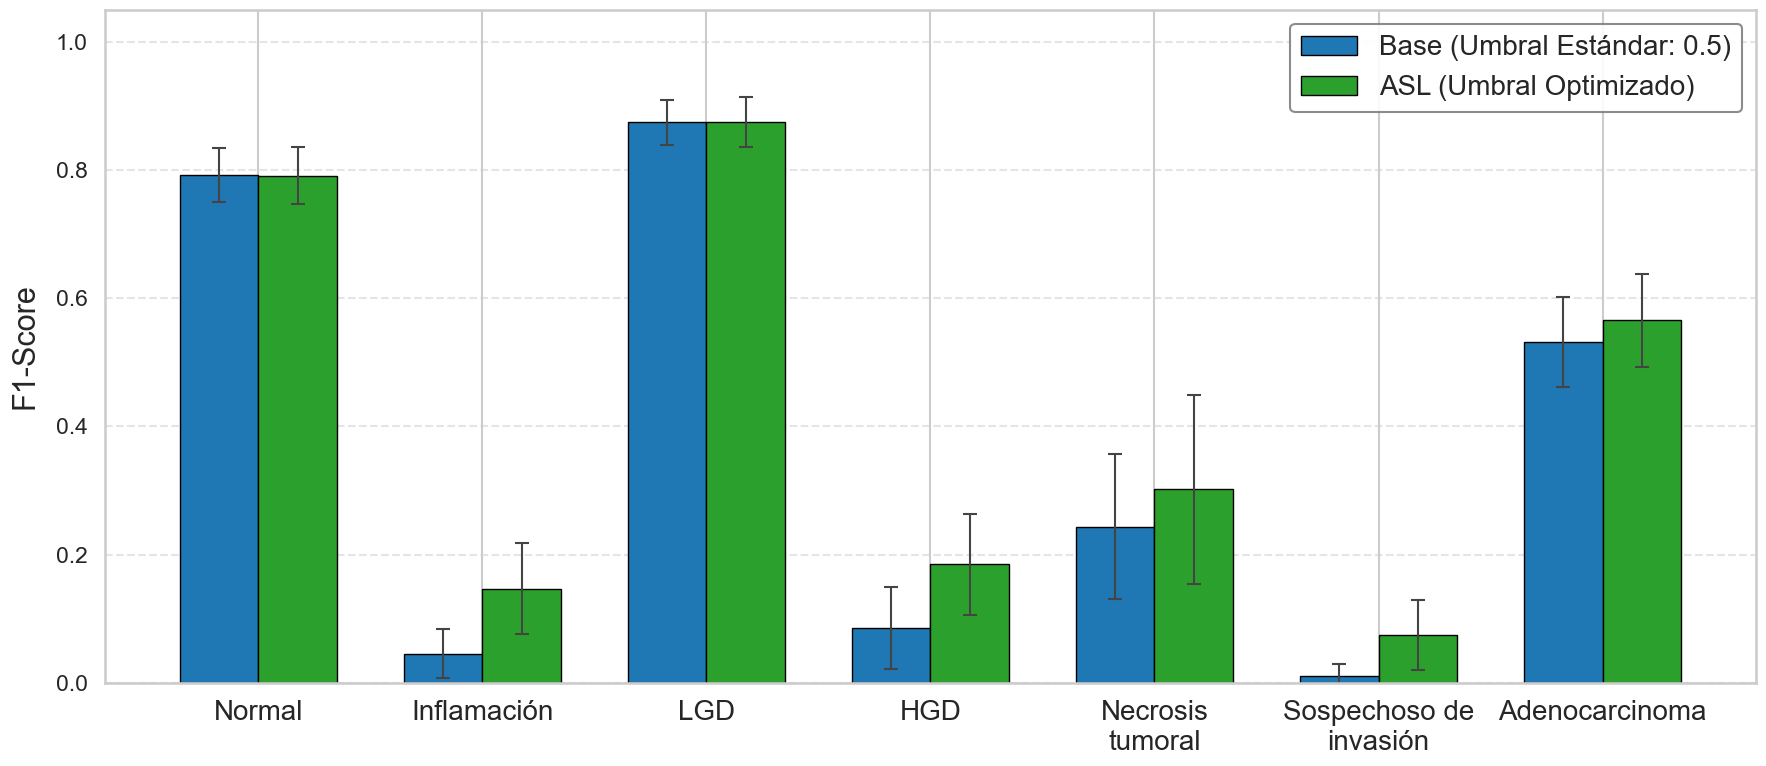

In [ ]:
import os
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURACIÓN DE PARÁMETROS
# ==========================================
DATA_DIR = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Metrics_multilabel')  

# Clases en el orden deseado
CLASSES = [
    'normal', 
    'inflammation', 
    'lowgrade_dysplasia', 
    'highgrade_dysplasia',
    'tumor_necrosis', 
    'suspicious_for_invasion', 
    'adenocarcinoma'
]

# Mapeo para los nombres en el eje X
MAPEO_NOMBRES = {
    "normal": "Normal",
    "inflammation": "Inflamación",
    "lowgrade_dysplasia": "LGD",
    "highgrade_dysplasia": "HGD",
    "tumor_necrosis": "Necrosis\ntumoral",          # Añadido \n para mejor lectura en el eje X
    "suspicious_for_invasion": "Sospechoso de\ninvasión", # Añadido \n para evitar solapamientos
    "adenocarcinoma": "Adenocarcinoma"
}

# Colores consistentes con los análisis anteriores
COLORS = {
    'Base': '#1f77b4',  # Azul
    'ASL': '#2ca02c'    # Verde
}

base_means, base_stds = [], []
asl_means, asl_stds = [], []

# Cargar datos de Base (Umbral por defecto 0.5)
base_json_path = DATA_DIR / "global_report_strategy_None_None.json"
with open(base_json_path, "r", encoding="utf-8") as f:
    base_data = json.load(f)

# Cargar datos de ASL (Umbral Optimizado)
asl_json_path = DATA_DIR / "global_report_strategy_None_ASL.json"
with open(asl_json_path, "r", encoding="utf-8") as f:
    asl_data = json.load(f)

# Extraer métricas para cada clase en el orden correcto
for class_name in CLASSES:
    # Base -> default_0.5
    base_metrics = base_data[class_name]["default_0.5"]["f1_score"]
    base_means.append(base_metrics["mean"])
    base_stds.append(base_metrics["std"])
    
    # ASL -> optimized
    asl_metrics = asl_data[class_name]["optimized"]["f1_score"]
    asl_means.append(asl_metrics["mean"])
    asl_stds.append(asl_metrics["std"])

# ==========================================
# CREACIÓN DEL GRÁFICO DE BARRAS AGRUPADAS
# ==========================================
x_labels = [MAPEO_NOMBRES[c] for c in CLASSES]
x_indices = np.arange(len(CLASSES))
width = 0.35  # Ancho de cada barra

fig, ax = plt.subplots(figsize=(18, 8))

# Dibujar las barras del modelo Base (Umbral 0.5) con sus barras de error
bars_base = ax.bar(
    x_indices - width/2, 
    base_means, 
    width, 
    yerr=base_stds, 
    label='Base (Umbral Estándar: 0.5)', 
    color=COLORS['Base'], 
    edgecolor='black',
    linewidth=1.0,
    capsize=5,          # Ancho de la barra transversal del error
    error_kw={'ecolor': '#444444', 'elinewidth': 1.5, 'capthick': 1.5}
)

# Dibujar las barras del modelo ASL (Umbral Optimizado) con sus barras de error
bars_asl = ax.bar(
    x_indices + width/2, 
    asl_means, 
    width, 
    yerr=asl_stds, 
    label='ASL (Umbral Optimizado)', 
    color=COLORS['ASL'], 
    edgecolor='black',
    linewidth=1.0,
    capsize=5,          # Ancho de la barra transversal del error
    error_kw={'ecolor': '#444444', 'elinewidth': 1.5, 'capthick': 1.5}
)

# Configuración estética del gráfico
ax.set_ylabel('F1-Score', fontsize=22, labelpad=12)
ax.set_xticks(x_indices)
ax.set_xticklabels(x_labels, fontsize=20, fontweight='medium')
ax.set_ylim([0.0, 1.05])

# Cuadrícula de fondo ligera solo para el eje Y
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True) # Asegura que las barras queden por encima de las líneas de la cuadrícula



ax.legend(loc='upper right', fontsize=20, framealpha=0.9, edgecolor='gray')

# Ajustar márgenes para que no se corten los textos largos de abajo
plt.tight_layout()

# Guardar la imagen
plt.savefig('comparativa_barras_f1_base_vs_asl.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# ==========================================
# CONFIGURACIÓN DEL EXPERIMENTO
# ==========================================
CLASSES = [
    'normal',
    'lowgrade_dysplasia',
    'inflammation',
    'highgrade_dysplasia',
    'tumor_necrosis',
    'suspicious_for_invasion',
    'adenocarcinoma',
]
ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output')


SEEDS = [22, 32, 42, 52, 62]  
FOLDS = [1, 2, 3, 4, 5]
METHODS = ['None_None', 'None_PW', 'None_ASL', 'WS_None']

COLORS = {
    'None_None': '#1f77b4', 
    'None_PW': '#2ca02c', 
    'None_ASL': '#d62728', 
    'WS_None': '#bcbd22' 
}


LABELS = {
    'None_None': 'Baseline (BCE)', 
    'None_PW': 'Pos Weights (PW)', 
    'None_ASL': 'Asymmetric Loss (ASL)',
    'WS_None': 'Weighted Sampler (WS)'
}

threshold_sweep = np.linspace(0.01, 0.99, 100)

# Estructura para almacenar las curvas de test de cada combinación
data_storage = {m: {c: {'test_curves': [], 'opt_t_val': [], 'test_f1_opt': []} for c in CLASSES + ['macro_average']} for m in METHODS}

# ==========================================
# EXTRACCIÓN Y PROCESAMIENTO DE DATOS
# ==========================================
print("Procesando archivos CSV y calculando espacios de fases...")

for seed in SEEDS:
    for fold in FOLDS:
        for method in METHODS:
            val_path = ROOT / f"predictions_seed_{seed}_fold{fold}_{method}_val.csv"
            test_path = ROOT / f"predictions_seed_{seed}_fold{fold}_{method}_test.csv"
            
            if not (val_path.exists() and test_path.exists()):
                continue
                
            df_val = pd.read_csv(val_path)
            df_test = pd.read_csv(test_path)
            
            run_macro_test_curve = np.zeros(len(threshold_sweep))
            run_macro_val_curve = np.zeros(len(threshold_sweep))
            
            # Calcular curvas por cada clase individual
            for cls in CLASSES:
                y_true_val = df_val[f"{cls}_true"].values
                y_prob_val = df_val[f"{cls}_prob"].values
                y_true_test = df_test[f"{cls}_true"].values
                y_prob_test = df_test[f"{cls}_prob"].values
                
                cls_val_curve = []
                cls_test_curve = []
                for t in threshold_sweep:
                    # Validación
                    pred_val = (y_prob_val >= t).astype(int)
                    cls_val_curve.append(f1_score(y_true_val, pred_val, zero_division=0))
                    # Test
                    pred_test = (y_prob_test >= t).astype(int)
                    cls_test_curve.append(f1_score(y_true_test, pred_test, zero_division=0))
                
                cls_test_curve = np.array(cls_test_curve)
                cls_val_curve = np.array(cls_val_curve)
                
                run_macro_test_curve += cls_test_curve / len(CLASSES)
                run_macro_val_curve += cls_val_curve / len(CLASSES)
                
                data_storage[method][cls]['test_curves'].append(cls_test_curve)
                
                best_t_idx = np.argmax(cls_val_curve)
                best_t = threshold_sweep[best_t_idx]
                data_storage[method][cls]['opt_t_val'].append(best_t)
                data_storage[method][cls]['test_f1_opt'].append(cls_test_curve[best_t_idx])
            
            # Guardar la métrica combinada Macro de este run
            data_storage[method]['macro_average']['test_curves'].append(run_macro_test_curve)
            best_macro_t_idx = np.argmax(run_macro_val_curve)
            data_storage[method]['macro_average']['opt_t_val'].append(threshold_sweep[best_macro_t_idx])
            data_storage[method]['macro_average']['test_f1_opt'].append(run_macro_test_curve[best_macro_t_idx])

# ==========================================
# GENERACIÓN DE IMÁGENES INDIVIDUALES
# ==========================================
print("\nGenerando gráficos individuales...")
plot_targets = CLASSES + ['macro_average']

for target in plot_targets:
    # Creamos un lienzo independiente para cada clase o métrica macro
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for method in METHODS:
        curves = np.array(data_storage[method][target]['test_curves'])
        if len(curves) == 0: 
            continue
        
        # Estadísticos de la curva continua (F1 vs Umbral)
        mean_curve = np.mean(curves, axis=0)
        std_curve = np.std(curves, axis=0)
        
        # Estadísticos del punto óptimo validado
        mean_t = np.mean(data_storage[method][target]['opt_t_val'])
        mean_f1 = np.mean(data_storage[method][target]['test_f1_opt'])
        
        # Línea continua de la media
        label_text = f"{LABELS[method]} ($\tau^* = {mean_t:.2f}$)"
        ax.plot(threshold_sweep, mean_curve, color=COLORS[method], linestyle='-', linewidth=2, label=label_text)
        
        # Banda de incertidumbre estadística
        ax.fill_between(threshold_sweep, mean_curve - std_curve, mean_curve + std_curve, 
                        color=COLORS[method], alpha=0.12)
        
        # Marcador del óptimo
        ax.plot(mean_t, mean_f1, marker='o', color=COLORS[method], markersize=8, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
        
    # Formato estético
    title_name = target.upper().replace('_', ' ')
    if target != 'macro_average':
        ax.set_title(f"Espacio de Calibración: Clase {title_name}", fontsize=13, fontweight='bold', pad=15)
    else:
        ax.set_title("RENDIMIENTO GLOBAL DEL SISTEMA (MACRO OVERALL)", fontsize=13, fontweight='bold', pad=15)
        
    ax.set_xlabel("Umbral de Clasificación ($\tau$)", fontsize=11)
    ax.set_ylabel("F1-Score (Test)", fontsize=11)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc="lower left", fontsize=10, frameon=True, shadow=True)
    
    plt.tight_layout()
    
    # Guardado individualizado de cada archivo
    filename = f"calibracion_{target}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)  # Cierra la figura actual para liberar la memoria RAM y evitar solapamientos
    print(f" -> Imagen exportada con éxito: {filename}")

print("\n¡Procesamiento completo!")

Procesando archivos CSV y calculando espacios de fases...

Generando gráficos individuales...
 -> Imagen exportada con éxito: calibracion_normal.png
 -> Imagen exportada con éxito: calibracion_lowgrade_dysplasia.png
 -> Imagen exportada con éxito: calibracion_inflammation.png
 -> Imagen exportada con éxito: calibracion_highgrade_dysplasia.png
 -> Imagen exportada con éxito: calibracion_tumor_necrosis.png
 -> Imagen exportada con éxito: calibracion_suspicious_for_invasion.png
 -> Imagen exportada con éxito: calibracion_adenocarcinoma.png
 -> Imagen exportada con éxito: calibracion_macro_average.png

¡Procesamiento completo! Revisa tu directorio de ejecución.


In [ ]:
import pandas as pd
import torch
from pathlib import Path 

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')

lista_resultados = []

SEEDS = [22, 32, 42, 52, 62]
NUM_FOLDS = 5

for fold in range(1, NUM_FOLDS + 1):
    for seed in SEEDS:
        csv_path = ROOT  / 'Model_output' / f'predictions_seed_{seed}_fold{fold}_None_ASL_test.csv'
        CKPT_DIR = ROOT / 'Model_output' / f'best_model_seed_{seed}_fold_{fold}_strategy_None_ASL.pth'
        checkpoint = torch.load(CKPT_DIR, map_location='cpu')
        umbral = checkpoint['thresholds']
        
        try:
            # Leer el CSV
            df = pd.read_csv(csv_path)
            
            # Identificar automáticamente las columnas dinámicas
            true_cols = [c for c in df.columns if c.endswith('_true')]
            prob_cols = [c for c in df.columns if c.endswith('_prob')]
            
            # Validar que el CSV tenga la estructura correcta
            if not true_cols or not prob_cols:
                print(f"Saltando '{csv_path}': No contiene el formato '_true' y '_prob'.")
                continue
            
            etiquetas_reales_por_fila = df[true_cols].sum(axis=1)
            etiquetas_predichas_por_fila = (df[prob_cols] >= umbral).sum(axis=1)
            
            # --- CÁLCULOS POR ARCHIVO ---
            eran_multilabel = etiquetas_reales_por_fila > 1
            predijo_multilabel = etiquetas_predichas_por_fila > 1
            eran_single_label = etiquetas_reales_por_fila == 1
            
            # M1: Reales multilabel
            total_eran_multilabel = eran_multilabel.sum()
            
            # M2: Bien predichos como multilabel (eran multilabel y el modelo vio > 1 etiqueta)
            multilabel_bien_identificado = (eran_multilabel & predijo_multilabel).sum()
            
            # M3: Mal predichos como multilabel (eran 1 sola etiqueta y el modelo vio > 1)
            falsos_multilabel = (eran_single_label & predijo_multilabel).sum()
            
            # Total de predicciones multilabel en este archivo (para el % final)
            total_predicho_multilabel = predijo_multilabel.sum()
            
            lista_resultados.append({
                'Archivo': csv_path,
                'Total_Casos': len(df),
                'Real_Multilabel': total_eran_multilabel,
                'Bien_Predicho_Multilabel': multilabel_bien_identificado,
                'Mal_Predicho_Multilabel': falsos_multilabel,
                'Total_Predicho_Multilabel': total_predicho_multilabel
            })
            
        except Exception as e:
            print(f" Error al procesar '{csv_path}': {e}")
        
# Convertir todos los resultados a un DataFrame final
df_informe = pd.DataFrame(lista_resultados)

if df_informe is not None and not df_informe.empty:
    print("\n REPORTE DE COMPORTAMIENTO MULTILABEL:")
    print(df_informe.to_string(index=False))
    
    df_informe.to_csv(ROOT / "acierto_multilabel_ASL.csv", index=False)
    print("\n ¡Reporte guardado como 'reporte_consolidado_multilabel.csv'!")
    
# =====================================================================
# CÁLCULO DE TOTALES GLOBALES (SUMATORIAS Y PORCENTAJES)
# =====================================================================
grand_total_casos = df_informe['Total_Casos'].sum()
grand_total_reales = df_informe['Real_Multilabel'].sum()
grand_total_bien_predichos = df_informe['Bien_Predicho_Multilabel'].sum()
grand_total_mal_predichos = df_informe['Mal_Predicho_Multilabel'].sum()
grand_total_predichos = df_informe['Total_Predicho_Multilabel'].sum()

# Calcular porcentajes globales sobre el total de casos
porcentaje_real_global = (grand_total_reales / grand_total_casos) * 100
porcentaje_predicho_global = (grand_total_predichos / grand_total_casos) * 100

print("\n" + "="*60)
print(" RESUMEN CONSOLIDADO DE LA CARPETA")
print("="*60)
print(f"• Total absoluto de casos analizados:   {grand_total_casos:,}")
print(f"• Total de casos REALES multilabel:     {grand_total_reales:,}")
print(f"• Total BIEN predichos como multilabel: {grand_total_bien_predichos:,}")
print(f"• Total MAL predichos (Falsos M-Label): {grand_total_mal_predichos:,}")
print("-"*60)
print(f"• PORCENTAJE REAL multilabel en el dataset:   {porcentaje_real_global:.2f}%")
print(f"• PORCENTAJE PREDICHO multilabel por modelo:  {porcentaje_predicho_global:.2f}%")
print("="*60)


📊 REPORTE DE COMPORTAMIENTO MULTILABEL:
                                                                                                          Archivo  Total_Casos  Real_Multilabel  Bien_Predicho_Multilabel  Mal_Predicho_Multilabel  Total_Predicho_Multilabel
C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output\predictions_seed_22_fold1_None_ASL_test.csv        20717              373                       248                     3558                       3806
C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output\predictions_seed_32_fold1_None_ASL_test.csv        19361              238                       140                     4545                       4685
C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output\predictions_seed_42_fold1_None_ASL_test.csv        16363               64                        19                     2311                       2330
C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output\p

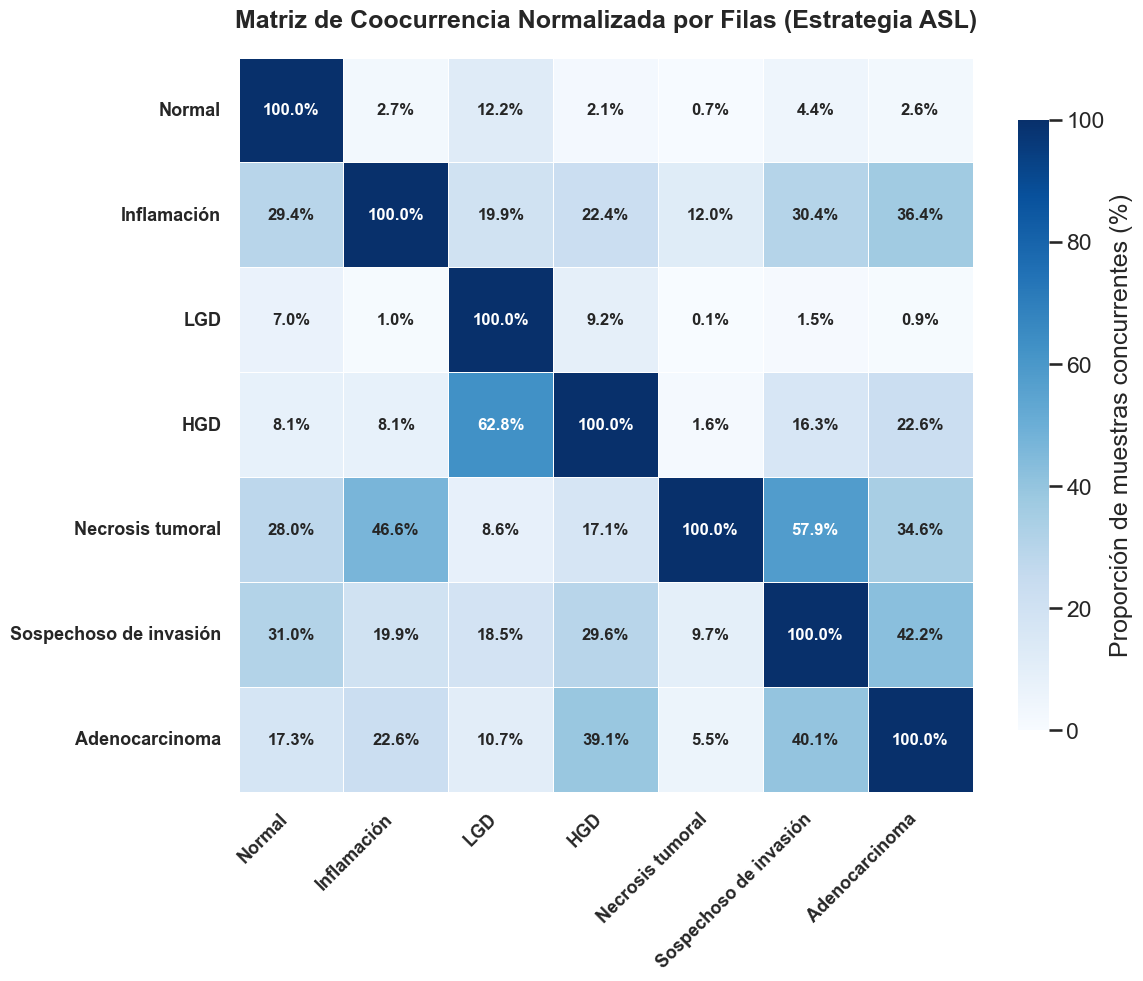

¡Matriz de porcentajes generada y guardada con éxito en C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\plots_interesantes\matriz_coocurrencia_porcentaje_ASL.png!


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
PATH_METRICS = ROOT / 'Metrics_multilabel'
PATH_OUTPUT = ROOT / 'Model_output'

SEEDS = [22, 32, 42, 52, 62]
FOLDS = [1, 2, 3, 4, 5]
METODO = "None_ASL"  # Filtrado exclusivo para la estrategia ASL

# Lista ordenada para mantener consistencia visual
CLASSES = [
    'normal', 
    'inflammation', 
    'lowgrade_dysplasia', 
    'highgrade_dysplasia',
    'tumor_necrosis', 
    'suspicious_for_invasion', 
    'adenocarcinoma'
]

# Diccionario de mapeo para los títulos en español
MAPEO_NOMBRES = {
    "normal": "Normal",
    "inflammation": "Inflamación",
    "lowgrade_dysplasia": "LGD",
    "highgrade_dysplasia": "HGD",
    "tumor_necrosis": "Necrosis tumoral",
    "suspicious_for_invasion": "Sospechoso de invasión",
    "adenocarcinoma": "Adenocarcinoma"
}

# Nombres formateados para los ejes del gráfico
nombres_espanol = [MAPEO_NOMBRES[c] for c in CLASSES]

# Lista para acumular todas las predicciones binarias
todas_las_predicciones = []

for seed in SEEDS:
    for fold in FOLDS:
        archivo_json = f"report_seed_{seed}_fold_{fold}_strategy_{METODO}.json"
        ruta_json = PATH_METRICS / archivo_json
        
        archivo_csv = f"predictions_seed_{seed}_fold{fold}_{METODO}_test.csv"
        ruta_csv = PATH_OUTPUT / archivo_csv
        
        if ruta_json.exists() and ruta_csv.exists():
            with open(ruta_json, 'r', encoding='utf-8') as f:
                data_json = json.load(f)
            
            df_pred = pd.read_csv(ruta_csv)
            predicciones_fold = {}
            
            for clase in CLASSES:
                try:
                    threshold = data_json[clase]["optimized"]["best_threshold"]
                except KeyError:
                    threshold = 0.5
                
                col_prob = f"{clase}_prob"
                if col_prob in df_pred.columns:
                    predicciones_fold[MAPEO_NOMBRES[clase]] = (df_pred[col_prob] >= threshold).astype(int)
            
            df_fold_binario = pd.DataFrame(predicciones_fold)
            todas_las_predicciones.append(df_fold_binario)

if todas_las_predicciones:
    df_final_binario = pd.concat(todas_las_predicciones, ignore_index=True)
    df_final_binario = df_final_binario[nombres_espanol]
    
    # Matriz de coocurrencia en valores absolutos (N)
    matriz_absoluta = df_final_binario.T.dot(df_final_binario)
    
    # Extraer los totales de cada clase (la diagonal absoluta)
    totales_por_clase = np.diag(matriz_absoluta)
    
    # Evitar división por cero en caso de que alguna clase no tenga predicciones
    totales_por_clase = np.where(totales_por_clase == 0, 1, totales_por_clase)
    
    # Normalizar por filas: dividir cada fila por su total y multiplicar por 100
    matriz_porcentaje = matriz_absoluta.div(totales_por_clase, axis=0) * 100
    
    if hasattr(matriz_porcentaje, 'map'):
        etiquetas_texto = matriz_porcentaje.map(lambda v: f"{v:.1f}%")
    else:
        etiquetas_texto = matriz_porcentaje.applymap(lambda v: f"{v:.1f}%")
    
    sns.set_theme(style="white", context="talk")
    plt.figure(figsize=(12, 10))
    
    sns.heatmap(
        matriz_porcentaje,
        annot=etiquetas_texto,       # Forzamos el texto con el símbolo % en las celdas
        fmt="",                      # Al pasar texto preformateado, dejamos fmt vacío
        cmap="Blues",                # Paleta secuencial azul
        square=True,                 # Celdas perfectamente cuadradas
        linewidths=.6,               # Separación fina entre bloques
        vmin=0,                      # El mínimo es 0%
        vmax=100,                    # El máximo es 100%
        cbar_kws={
            "label": "Proporción de muestras concurrentes (%)", 
            "shrink": 0.82
        },
        annot_kws={
            "size": 12,              # Tamaño ajustado para que quepa bien el texto con el %
            "weight": "bold"
        }
    )
    
    # Ajustes estéticos formales
    plt.title("Matriz de Coocurrencia Normalizada por Filas (Estrategia ASL)", fontsize=18, fontweight='bold', pad=22)
    plt.xticks(rotation=45, ha='right', fontsize=13, fontweight='bold')
    plt.yticks(rotation=0, fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    
    # Guardar gráfico
    (ROOT / 'plots_interesantes').mkdir(parents=True, exist_ok=True)
    ruta_guardado = ROOT / 'plots_interesantes' / "matriz_coocurrencia_porcentaje_ASL.png"
    plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"¡Matriz de porcentajes generada y guardada con éxito en {ruta_guardado}!")
else:
    print("Error: No se pudieron cargar los datos.")

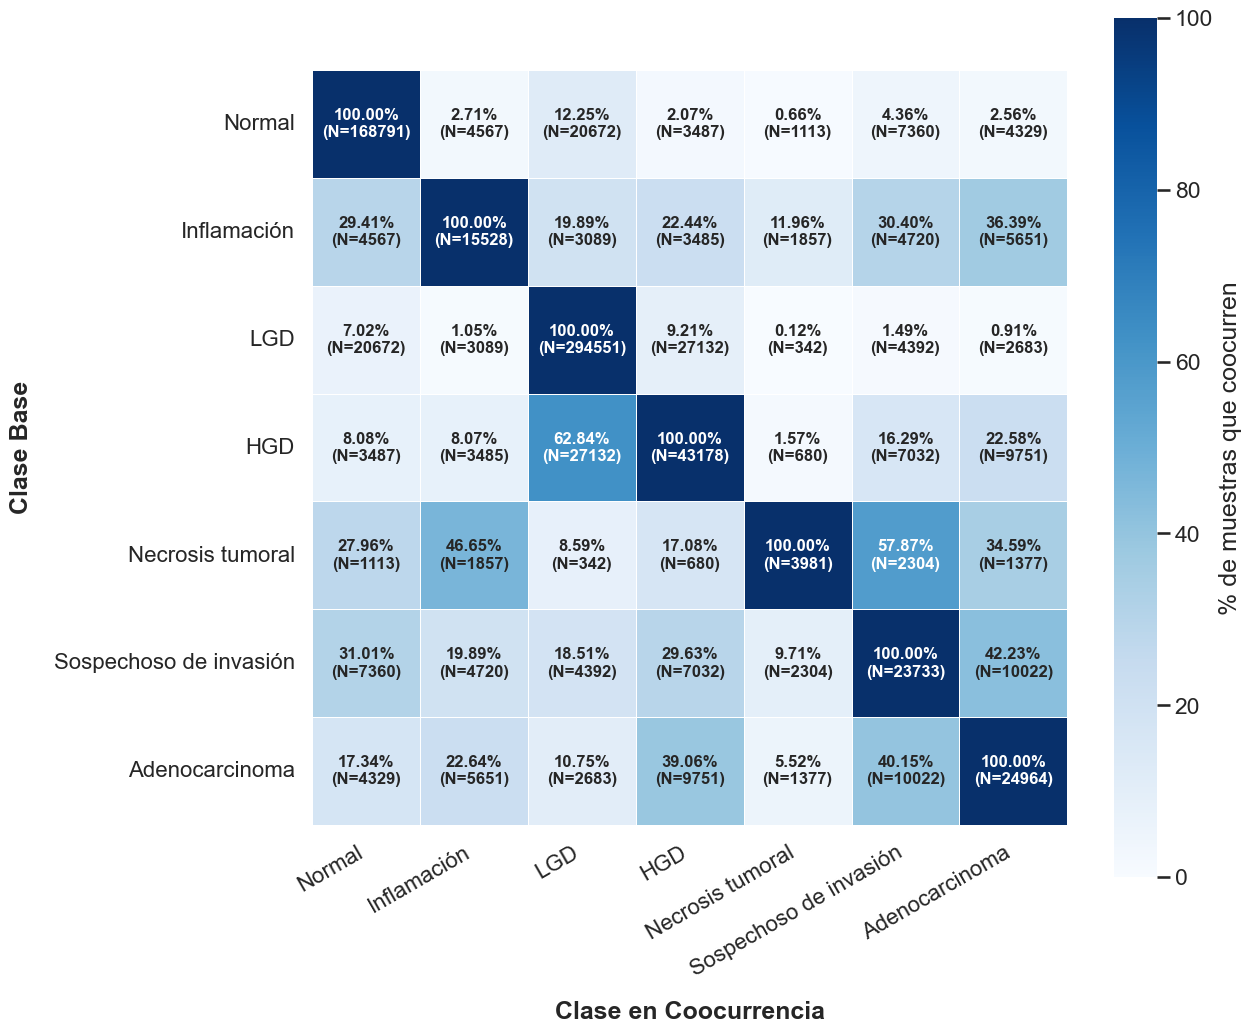

In [ ]:
import os
import json
import itertools
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
PATH_METRICS = ROOT / 'Metrics_multilabel'
PATH_OUTPUT = ROOT / 'Model_output'

SEEDS = [22, 32, 42, 52, 62]
FOLDS = [1, 2, 3, 4, 5]
METODO = "None_ASL"  # Filtrado exclusivo para la estrategia ASL

CLASSES = [
    'normal', 
    'inflammation', 
    'lowgrade_dysplasia', 
    'highgrade_dysplasia',
    'tumor_necrosis', 
    'suspicious_for_invasion', 
    'adenocarcinoma'
]

MAPEO_NOMBRES = {
    "normal": "Normal",
    "inflammation": "Inflamación",
    "lowgrade_dysplasia": "LGD",
    "highgrade_dysplasia": "HGD",
    "tumor_necrosis": "Necrosis tumoral",
    "suspicious_for_invasion": "Sospechoso de invasión",
    "adenocarcinoma": "Adenocarcinoma"
}

CLASES_ORDENADAS = [MAPEO_NOMBRES[c] for c in CLASSES]

# Lista para acumular todas las predicciones binarias antes de armar el Counter
todas_las_predicciones = []

for seed in SEEDS:
    for fold in FOLDS:
        archivo_json = f"report_seed_{seed}_fold_{fold}_strategy_{METODO}.json"
        ruta_json = PATH_METRICS / archivo_json
        
        archivo_csv = f"predictions_seed_{seed}_fold{fold}_{METODO}_test.csv"
        ruta_csv = PATH_OUTPUT / archivo_csv
        
        if ruta_json.exists() and ruta_csv.exists():
            with open(ruta_json, 'r', encoding='utf-8') as f:
                data_json = json.load(f)
            
            df_pred = pd.read_csv(ruta_csv)
            predicciones_fold = {}
            
            for clase in CLASSES:
                try:
                    threshold = data_json[clase]["optimized"]["best_threshold"]
                except KeyError:
                    threshold = 0.5
                
                col_prob = f"{clase}_prob"
                if col_prob in df_pred.columns:
                    predicciones_fold[MAPEO_NOMBRES[clase]] = (df_pred[col_prob] >= threshold).astype(int)
            
            df_fold_binario = pd.DataFrame(predicciones_fold)
            todas_las_predicciones.append(df_fold_binario)


if todas_las_predicciones:
    df_final_binario = pd.concat(todas_las_predicciones, ignore_index=True)
    df_final_binario = df_final_binario[CLASES_ORDENADAS]
    
    global_counter = Counter()
    totales_absolutos_clase = {clase: 0 for clase in CLASES_ORDENADAS}
    
    # Recorremos cada muestra (fila) para agrupar las predicciones positivas
    for _, row in df_final_binario.iterrows():
        # Filtramos qué clases se han activado (valor igual a 1) en esta muestra
        clases_activas = [clase for clase in CLASES_ORDENADAS if row[clase] == 1]
        
        if clases_activas:
            # Guardamos el conjunto de clases concurrentes como una tupla en el Counter
            global_counter[tuple(clases_activas)] += 1
            # Sumamos de forma independiente al total de la clase para la diagonal
            for clase in clases_activas:
                totales_absolutos_clase[clase] += 1

    # =========================================================
    # GENERACIÓN DE LA MATRIZ DE COOCURRENCIA
    # =========================================================

    # Inicializar la matriz vacía con el orden solicitado
    matriz_bruta = pd.DataFrame(0, index=CLASES_ORDENADAS, columns=CLASES_ORDENADAS)

    # Llenar las coocurrencias
    for combo, count in global_counter.items():
        for c1, c2 in itertools.combinations(combo, 2):
            matriz_bruta.loc[c1, c2] += count
            matriz_bruta.loc[c2, c1] += count  # Simetría inicial en valores absolutos

    # Llenar la diagonal principal con los totales absolutos que guardamos en el bucle
    for clase in CLASES_ORDENADAS:
        matriz_bruta.loc[clase, clase] = totales_absolutos_clase[clase]

    # Calcular la matriz de porcentajes
    totales_clase_base = pd.Series(np.diag(matriz_bruta), index=matriz_bruta.index)
    totales_clase_base = totales_clase_base.replace(0, 1) # Seguridad contra divisiones por 0
    
    matriz_porcentual = matriz_bruta.div(totales_clase_base, axis=0) * 100
    matriz_porcentual = matriz_porcentual.fillna(0)  # Evita errores si una clase tiene 0 muestras totales

    # Construir las etiquetas de texto personalizadas de doble línea
    matriz_texto = pd.DataFrame("", index=CLASES_ORDENADAS, columns=CLASES_ORDENADAS)
    for fila in CLASES_ORDENADAS:
        for columna in CLASES_ORDENADAS:
            pct = matriz_porcentual.loc[fila, columna]
            n_parches = int(matriz_bruta.loc[fila, columna])
            # Mantiene los dos decimales solicitados
            matriz_texto.loc[fila, columna] = f"{pct:.2f}%\n(N={n_parches})"

    # Configurar y dIbujar el Mapa de Calor
    sns.set_theme(style="white", context="talk")
    plt.figure(figsize=(13, 11))

    sns.heatmap(
        matriz_porcentual,
        annot=matriz_texto,
        fmt="",
        cmap="Blues",  # Escala completa de azules (los ceros quedan con fondo claro/blanco)
        linewidths=0.5,
        annot_kws={"size": 12, "weight": "semibold"},
        cbar_kws={"label": "% de muestras que coocurren"},
        vmin=0, vmax=100,
        square=True  # Mantiene las celdas perfectamente cuadradas
    )

    plt.xlabel("Clase en Coocurrencia", fontsize=18, fontweight="bold", labelpad=15)
    plt.ylabel("Clase Base", fontsize=18, fontweight="bold", labelpad=15)

    plt.xticks(rotation=30, ha="right", fontsize=16)
    plt.yticks(rotation=0, fontsize=16)
    plt.tight_layout()

    # Guardar automáticamente el gráfico
    (ROOT / 'plots_interesantes').mkdir(parents=True, exist_ok=True)
    plt.savefig(ROOT / 'plots_interesantes' / "matriz_coocurrencia_counter_ASL.png", dpi=300, bbox_inches='tight')
    
    # Mostrar el gráfico en pantalla
    plt.show()
else:
    print("Error: No se pudieron cargar los archivos CSV o JSON.")

In [ ]:
import pandas as pd
import torch
from pathlib import Path 

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')

lista_resultados = []

SEEDS = [22, 32, 42, 52, 62]
NUM_FOLDS = 5

for fold in range(1, NUM_FOLDS + 1):
    for seed in SEEDS:
        csv_path = ROOT / 'Model_output' / f'predictions_seed_{seed}_fold{fold}_None_PW_val.csv'
        CKPT_DIR = ROOT / 'Model_output' / f'best_model_seed_{seed}_fold_{fold}_strategy_None_PW.pth'
        checkpoint = torch.load(CKPT_DIR, map_location='cpu')
        umbral = checkpoint['thresholds']
        
        try:
            # Leer el CSV
            df = pd.read_csv(csv_path)
            
            # Identificar automáticamente las columnas dinámicas
            true_cols = [c for c in df.columns if c.endswith('_true')]
            prob_cols = [c for c in df.columns if c.endswith('_prob')]
            
            # Validar que el CSV tenga la estructura correcta
            if not true_cols or not prob_cols:
                print(f"Saltando '{csv_path}': No contiene el formato '_true' y '_prob'.")
                continue
            
            etiquetas_reales_por_fila = df[true_cols].sum(axis=1)
            etiquetas_predichas_por_fila = (df[prob_cols] >= umbral).sum(axis=1)
            
            # El modelo no predijo ninguna clase (todas las probabilidades quedaron por debajo del umbral)
            predijo_vacilante = etiquetas_predichas_por_fila == 0
            
            # Casos donde realmente no había ninguna etiqueta
            eran_vacias = etiquetas_reales_por_fila == 0
            
            # Casos donde el modelo predijo todo negativo, pero EN REALIDAD sí tenían al menos una clase positiva
            falsos_vacios = (etiquetas_reales_por_fila >= 1) & predijo_vacilante
            
            # Estadísticas para el informe
            total_eran_vacias = eran_vacias.sum()
            vacias_bien_identificadas = (eran_vacias & predijo_vacilante).sum()
            total_falsos_vacios = falsos_vacios.sum()
            total_predicho_vacias = predijo_vacilante.sum()
            
            lista_resultados.append({
                'Archivo': csv_path.name,
                'Total_Casos': len(df),
                'Real_Sin_Etiqueta': total_eran_vacias,
                'Bien_Predicho_Vacias': vacias_bien_identificadas,
                'Falsos_Vacios (Error)': total_falsos_vacios,
                'Total_Predicho_Vacias': total_predicho_vacias
            })
            
        except Exception as e:
            print(f" Error al procesar '{csv_path}': {e}")
        
# Convertir todos los resultados a un DataFrame final
df_informe = pd.DataFrame(lista_resultados)

if df_informe is not None and not df_informe.empty:
    print("\n REPORTE DE COMPORTAMIENTO (SIN PREDICCIÓN DEL MODELO):")
    print(df_informe.to_string(index=False))
    
    
# =====================================================================
# CÁLCULO DE TOTALES GLOBALES (SUMATORIAS Y PORCENTAJES)
# =====================================================================
grand_total_casos = df_informe['Total_Casos'].sum()
grand_total_reales = df_informe['Real_Sin_Etiqueta'].sum()
grand_total_bien_predichos = df_informe['Bien_Predicho_Vacias'].sum()
grand_total_mal_predichos = df_informe['Falsos_Vacios (Error)'].sum()
grand_total_predichos = df_informe['Total_Predicho_Vacias'].sum()

# Calcular porcentajes globales sobre el total de casos
porcentaje_real_global = (grand_total_reales / grand_total_casos) * 100 if grand_total_casos > 0 else 0
porcentaje_predicho_global = (grand_total_predichos / grand_total_casos) * 100 if grand_total_casos > 0 else 0

print("\n" + "="*60)
print(" RESUMEN CONSOLIDADO DE IMÁGENES VACÍAS (TODAS LAS CLASES NEGATIVAS)")
print("="*60)
print(f"• Total absoluto de casos analizados:         {grand_total_casos:,}")
print(f"• Total de casos REALES sin etiqueta:         {grand_total_reales:,}")
print(f"• Total BIEN predichos sin etiqueta:          {grand_total_bien_predichos:,}")
print(f"• Total MAL predichos (Falsos Vacíos):        {grand_total_mal_predichos:,}")
print(f"• TOTAL DE IMÁGENES QUE EL MODELO DEJÓ VACÍAS: {grand_total_predichos:,}")
print("-"*60)
print(f"• PORCENTAJE REAL sin etiqueta en el dataset: {porcentaje_real_global:.2f}%")
print(f"• PORCENTAJE PREDICHO vacío por el modelo:     {porcentaje_predicho_global:.2f}%")
print("="*60)


📊 REPORTE DE COMPORTAMIENTO (SIN PREDICCIÓN DEL MODELO):
                                  Archivo  Total_Casos  Real_Sin_Etiqueta  Bien_Predicho_Vacias  Falsos_Vacios (Error)  Total_Predicho_Vacias
predictions_seed_22_fold1_None_PW_val.csv        19089                  0                     0                    383                    383
predictions_seed_32_fold1_None_PW_val.csv        21482                  0                     0                    481                    481
predictions_seed_42_fold1_None_PW_val.csv        23757                  0                     0                    374                    374
predictions_seed_52_fold1_None_PW_val.csv        19502                  0                     0                    275                    275
predictions_seed_62_fold1_None_PW_val.csv        16518                  0                     0                    299                    299
predictions_seed_22_fold2_None_PW_val.csv        20717                  0                 

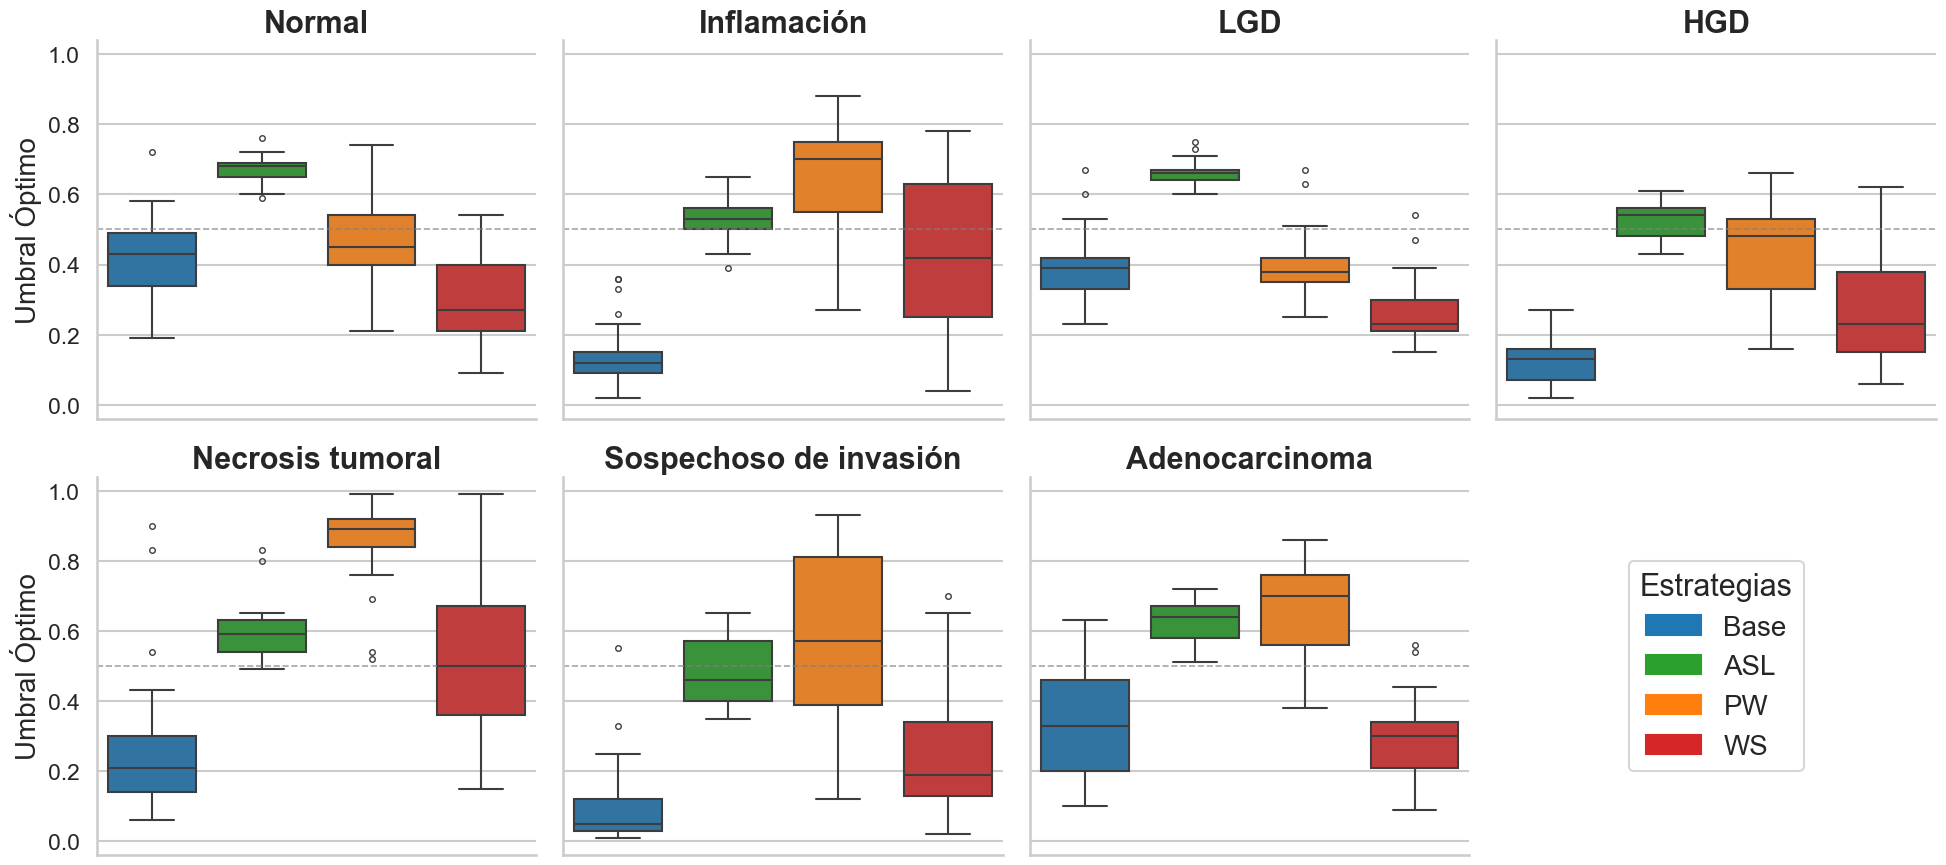

In [ ]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.patches as mpatches


ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')


LEYENDA_PERSONALIZADA = {
    "None_None": "Base",
    "None_ASL" : "ASL",  
    "None_PW"  : "PW",
    "WS_None"  : "WS"
}


CLASSES = [
    'normal', 
    'inflammation', 
    'lowgrade_dysplasia', 
    'highgrade_dysplasia',
    'tumor_necrosis', 
    'suspicious_for_invasion', 
    'adenocarcinoma'
]

MAPEO_NOMBRES = {
    "normal": "Normal",
    "inflammation": "Inflamación",
    "lowgrade_dysplasia": "LGD",
    "highgrade_dysplasia": "HGD",
    "tumor_necrosis": "Necrosis tumoral",
    "suspicious_for_invasion": "Sospechoso de invasión",
    "adenocarcinoma": "Adenocarcinoma"
}

COLORS = {
    'Base': '#1f77b4',  # Azul
    'ASL': '#2ca02c',   # Verde
    'PW': '#ff7f0e',    # Naranja
    'WS': '#d62728'     # Rojo
}

SEEDS = [22, 32, 42, 52, 62]
NUM_FOLDS = 5

METODOS = ["None_None", "None_ASL", "None_PW", "WS_None"] 
FOLDS = list(range(1, NUM_FOLDS + 1)) 

registros = []

for seed in SEEDS:
    for fold in FOLDS:
        for metodo in METODOS:
            nombre_archivo = f"report_seed_{seed}_fold_{fold}_strategy_{metodo}.json"
            ruta_completa = os.path.join(ROOT / 'Metrics_multilabel', nombre_archivo)
            
            if os.path.exists(ruta_completa):
                with open(ruta_completa, 'r') as f:
                    data = json.load(f)
                
                for clase, metricas in data.items():
                    if "optimized" in metricas and "best_threshold" in metricas["optimized"]:
                        threshold = metricas["optimized"]["best_threshold"]
                        registros.append({
                            "Method": metodo, 
                            "Class": clase,
                            "Best_Threshold": threshold
                        })

df = pd.DataFrame(registros)

if not df.empty:
    # Mapear y ordenar los métodos
    df["Method"] = df["Method"].map(LEYENDA_PERSONALIZADA)
    orden_metodos = [LEYENDA_PERSONALIZADA[m] for m in METODOS]
    df["Method"] = pd.Categorical(df["Method"], categories=orden_metodos, ordered=True)

    # Mapear y ordenar las clases (Asegura el orden exacto en los subplots)
    df["Class"] = df["Class"].map(MAPEO_NOMBRES)
    orden_clases = [MAPEO_NOMBRES[c] for c in CLASSES]
    df["Class"] = pd.Categorical(df["Class"], categories=orden_clases, ordered=True)

    sns.set_theme(style="whitegrid", context="talk")
    
    g = sns.catplot(
        data=df,
        x="Method",
        y="Best_Threshold",
        hue="Method",
        hue_order=orden_metodos,        
        col="Class",
        col_order=orden_clases,        
        col_wrap=4,                    
        kind="box",
        palette=COLORS,                
        height=4.5,
        aspect=1.1,
        sharey=True,
        linewidth=1.5,
        fliersize=4,
        legend=False                   
    )
    
    # Configuración de líneas de referencia y limpieza de ejes
    for ax in g.axes.flat:
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7, linewidth=1.2)
        ax.set_xticklabels([])          
        ax.set_xlabel("")
        
    g.set_titles("{col_name}", weight='bold', size=22)
    g.set_axis_labels("", "Umbral Óptimo", size=20)
    
    ax_vacio = g.fig.add_subplot(2, 4, 8)
    ax_vacio.axis('off') # Ocultamos los ejes del octavo cuadrante
    
    # Creamos los cuadros de la leyenda respetando el nuevo orden secuencial
    handles_manuales = [
        mpatches.Patch(color=COLORS[nombre], label=nombre)
        for nombre in orden_metodos
    ]
    
    # Forzamos el renderizado de la leyenda con las etiquetas correctas
    ax_vacio.legend(
        handles=handles_manuales, 
        title="Estrategias", 
        loc="center",         
        frameon=True,
        shadow=False,
        fontsize=20,
        title_fontsize=22
    )
    
    plt.tight_layout()
    
    # Asegurar que existe la carpeta de guardado
    (ROOT / 'plots_interesantes').mkdir(parents=True, exist_ok=True)
    
    plt.savefig(ROOT / 'plots_interesantes' / "distribucion_thresholds.png", dpi=300, bbox_inches='tight')
    plt.show()

🚀 Iniciando la acumulación de predicciones...
✅ Conteo acumulado finalizado con éxito.


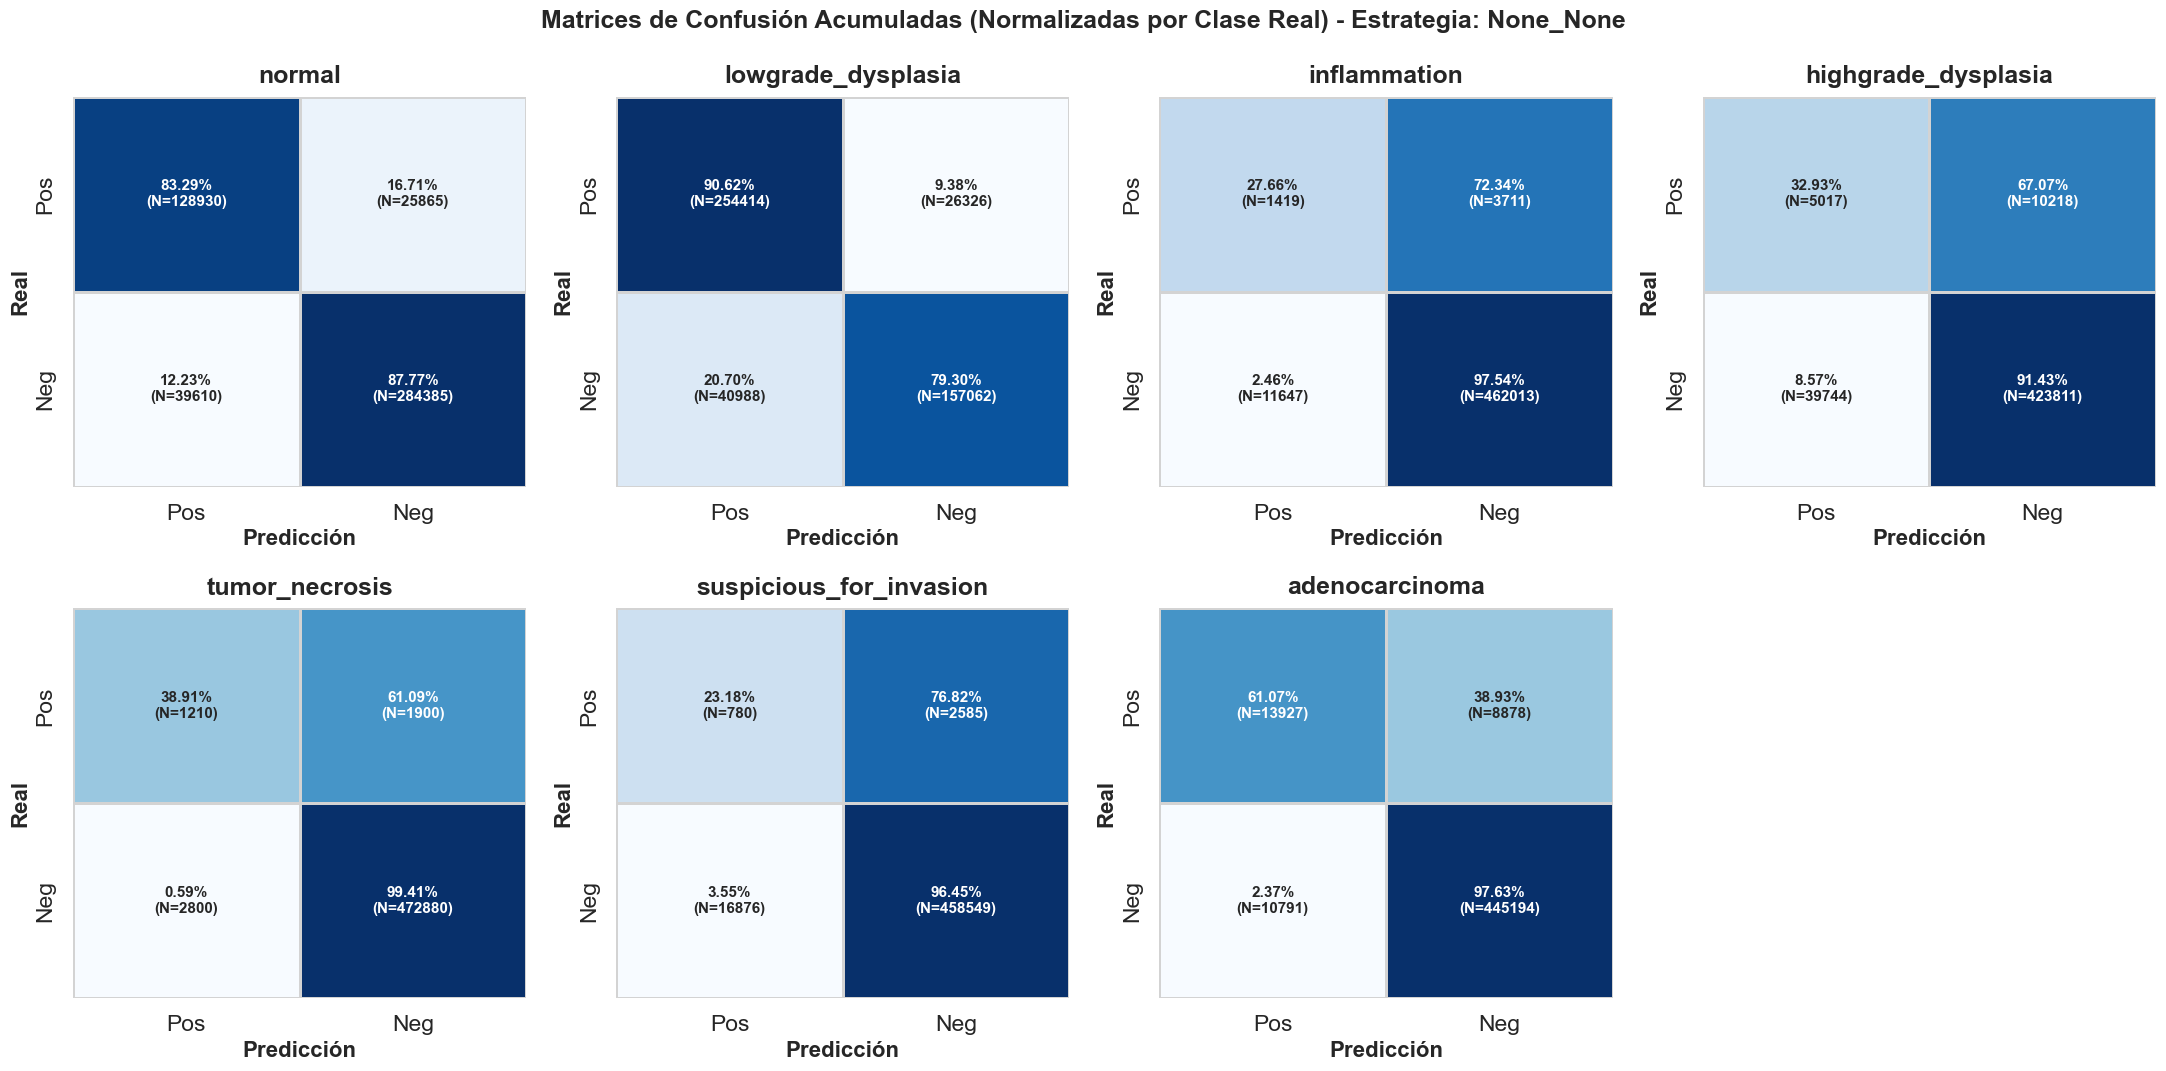

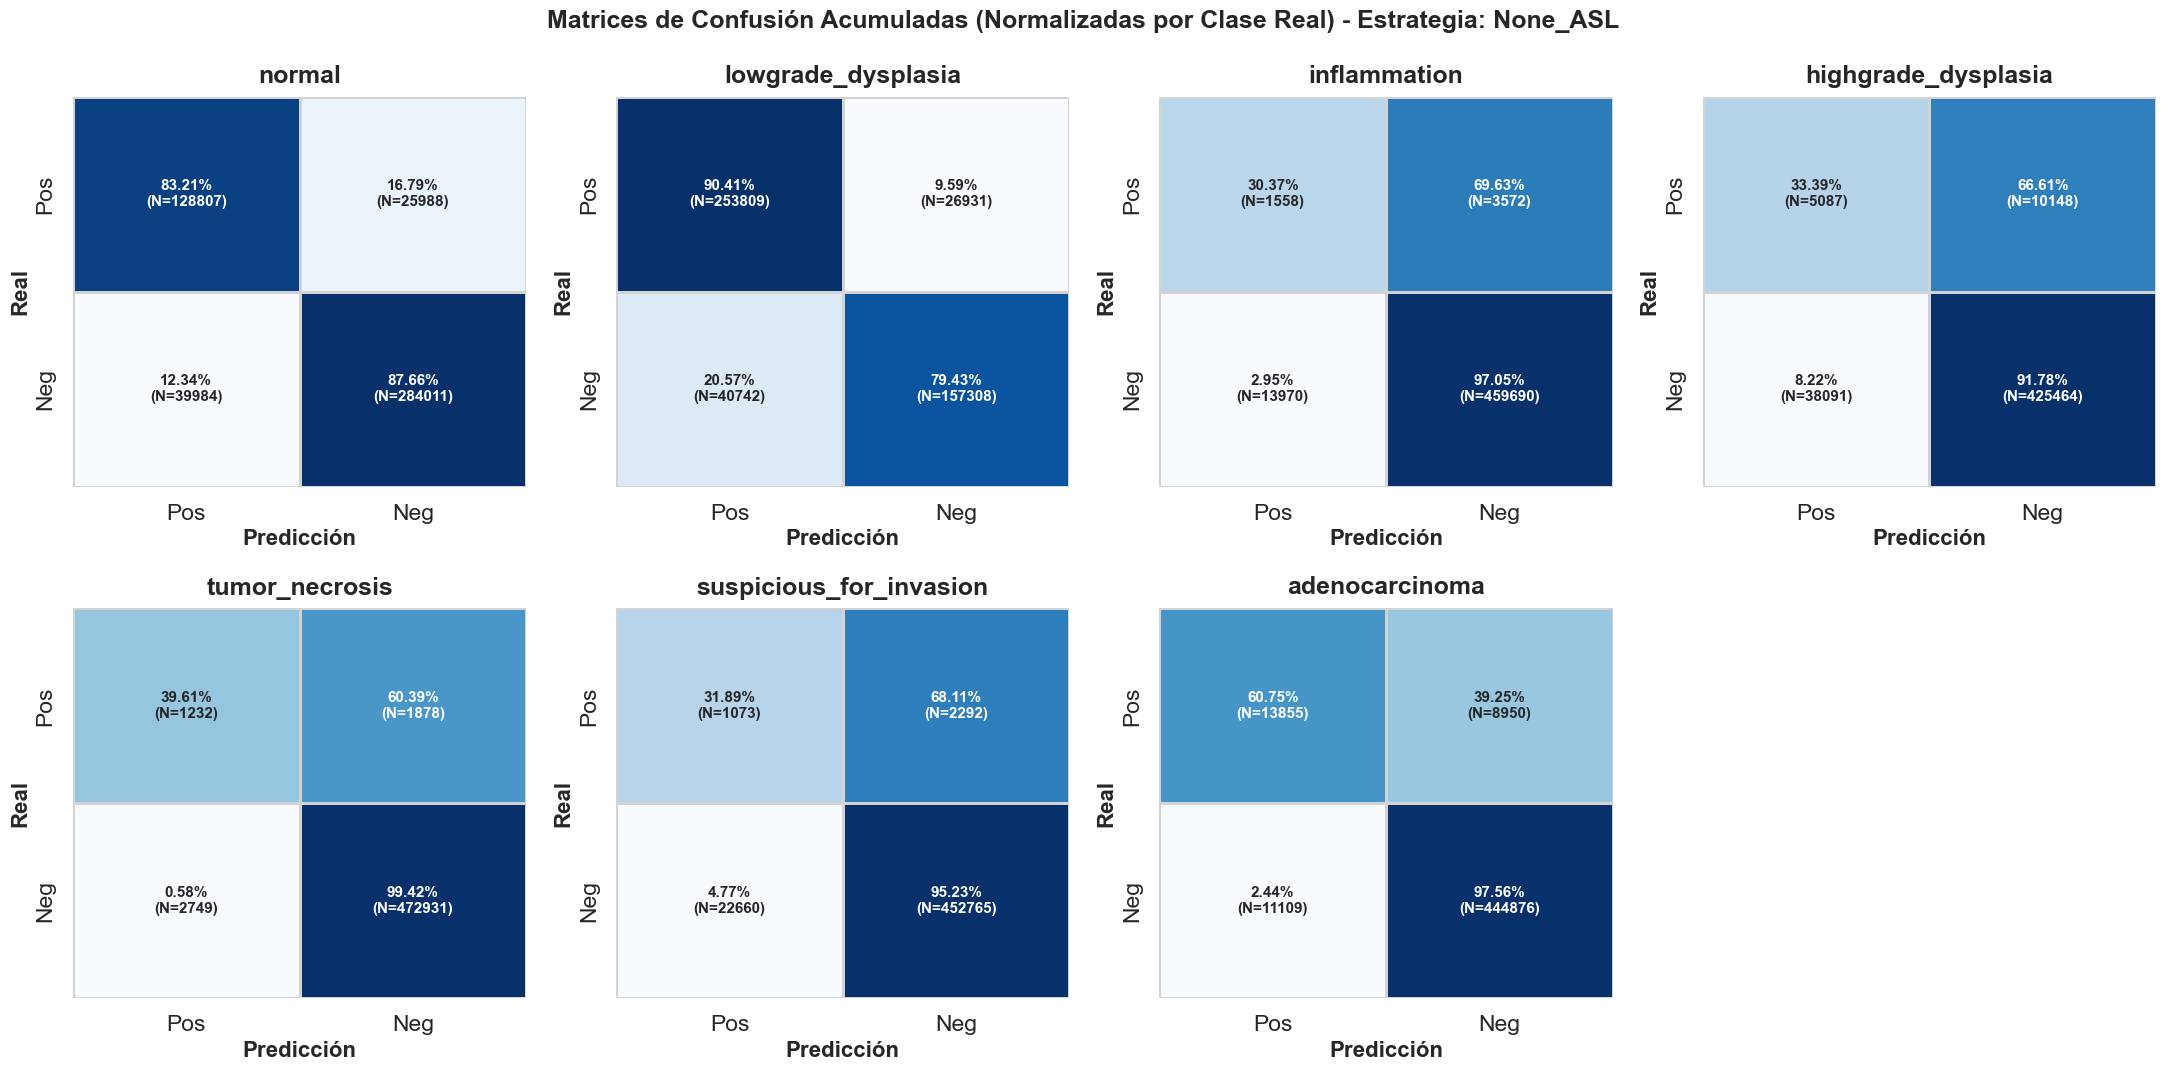

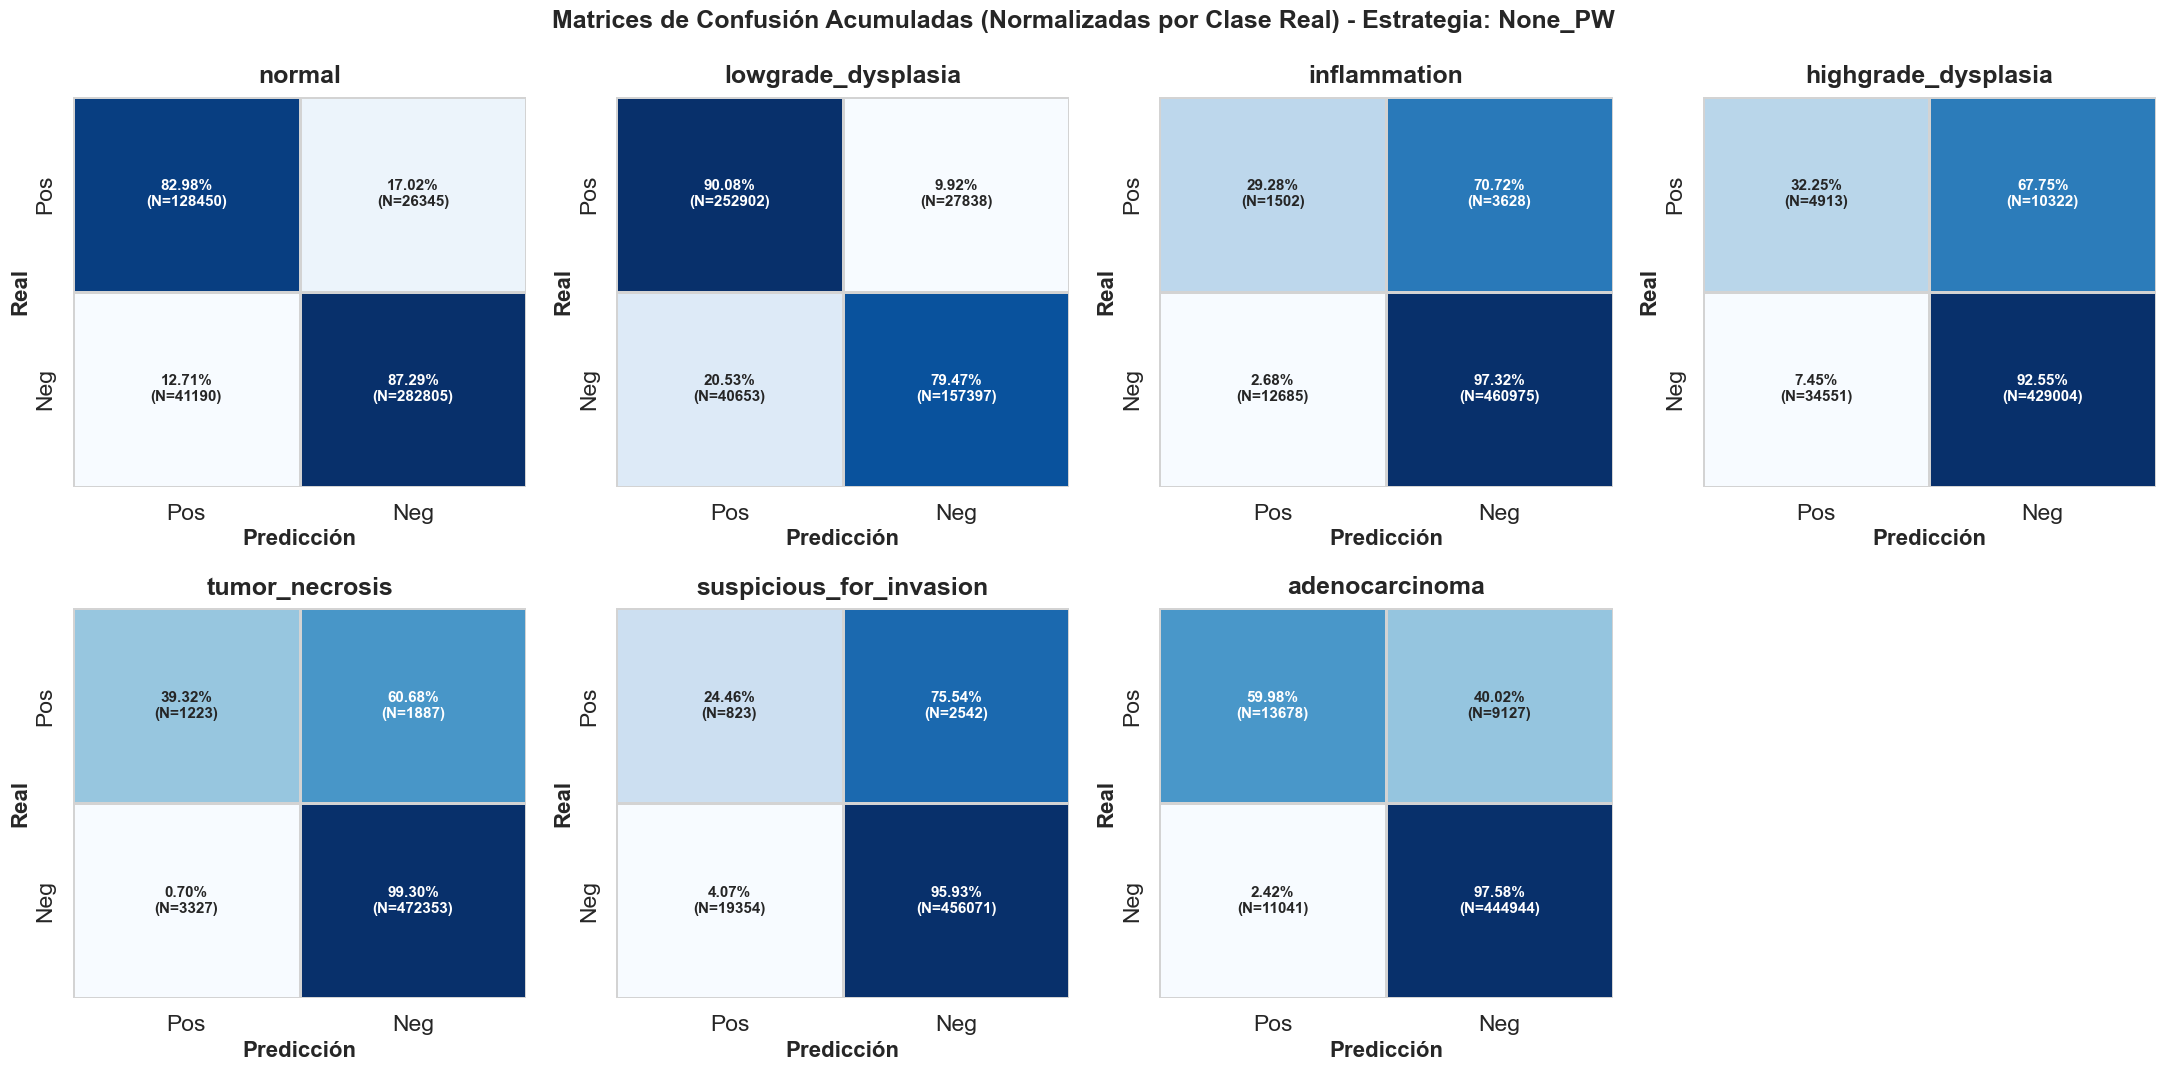

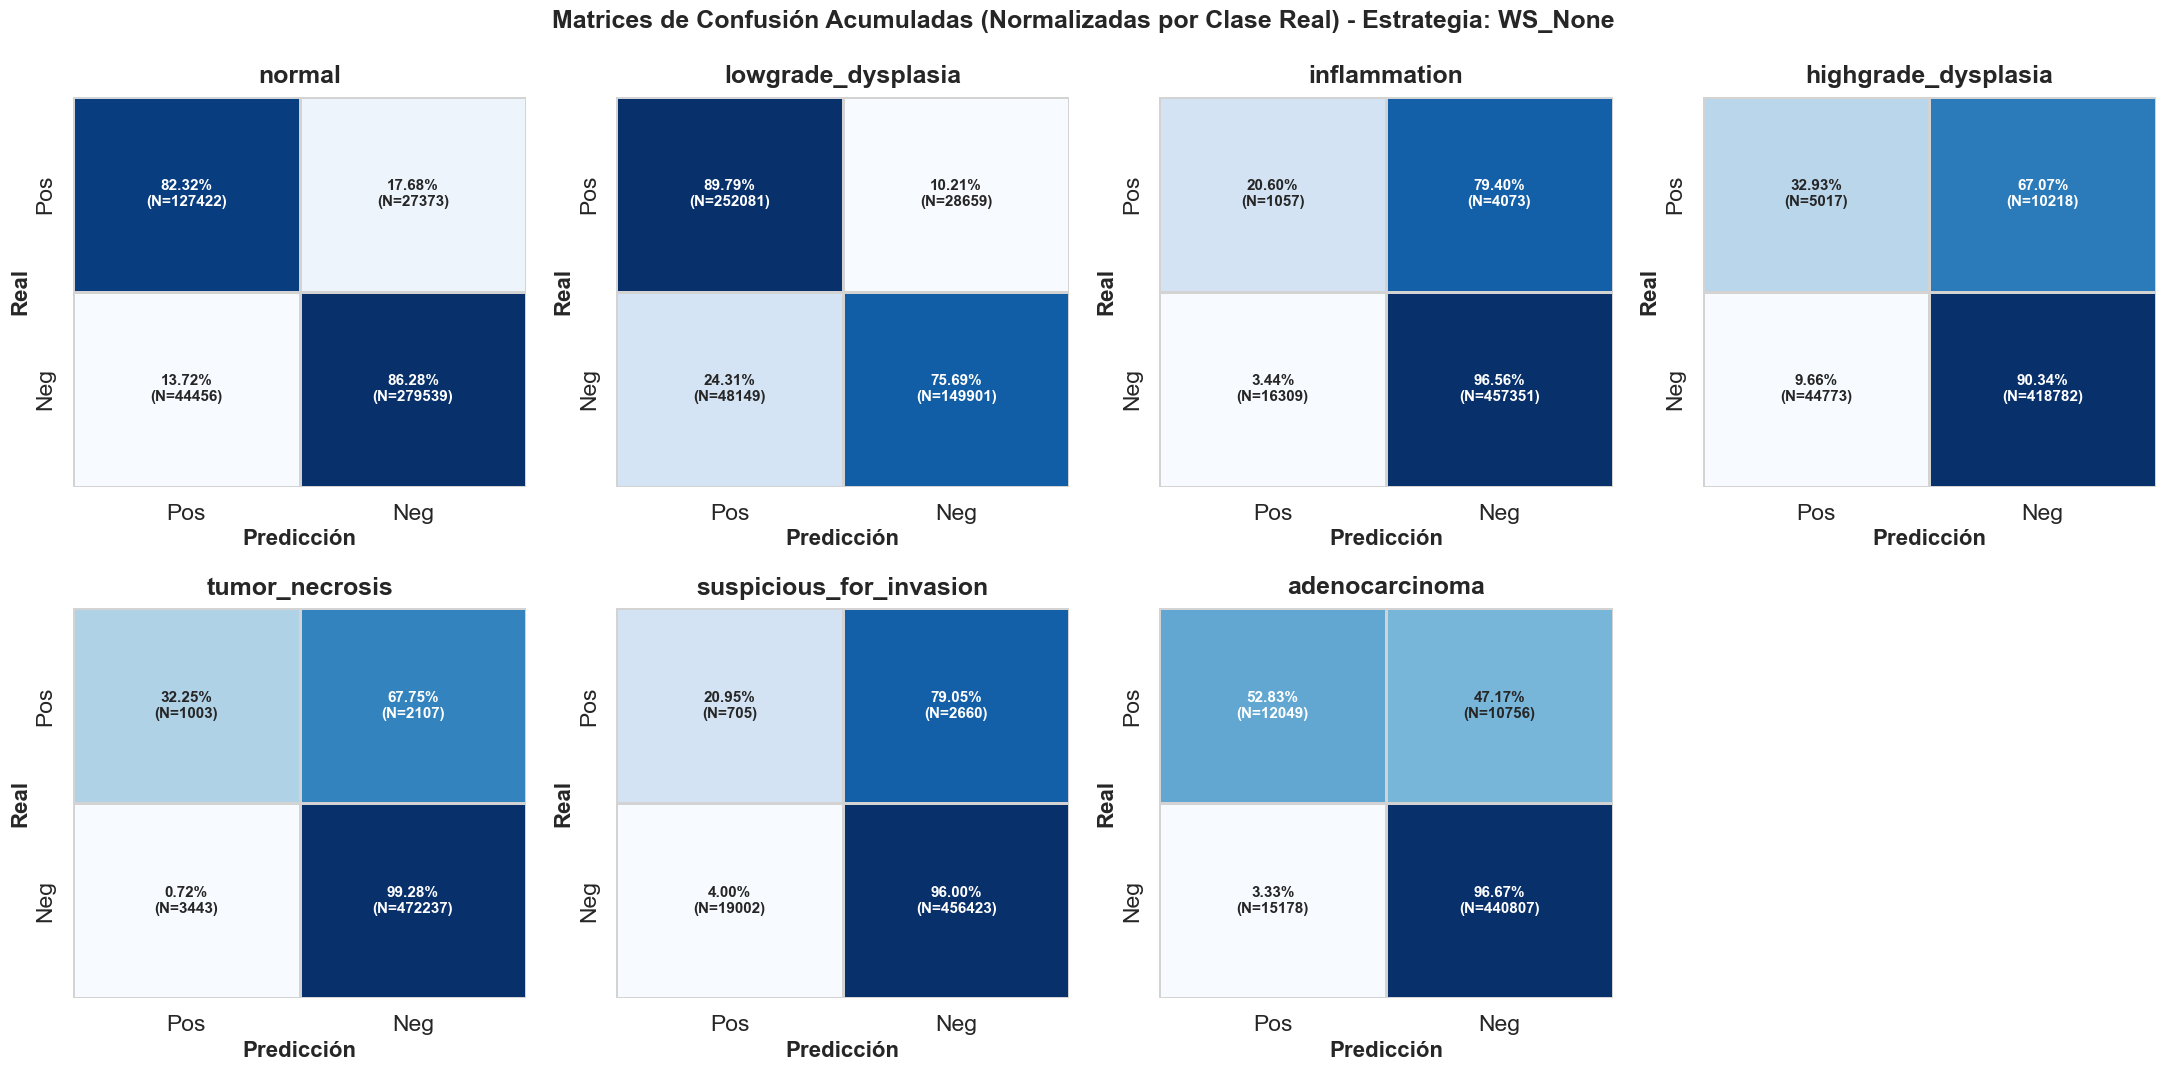

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path 

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
DATA_DIR = ROOT / 'Model_output'

SEEDS = [22, 32, 42, 52, 62]
FOLDS = [1, 2, 3, 4, 5]
ESTRATEGIAS = ["None_None", "None_ASL", "None_PW", "WS_None"]
CLASES = ["normal", "lowgrade_dysplasia", "inflammation", "highgrade_dysplasia", "tumor_necrosis", "suspicious_for_invasion", "adenocarcinoma"]

def cargar_predicciones_del_usuario(seed, fold, estrategia):
    """
    Carga las predicciones desde un archivo CSV para una combinación específica
    de semilla, fold y estrategia.
    
    Retorna un diccionario: 
    {
        "nombre_clase": (y_true_array, y_prob_array),
        ...
    }
    """
    # Construimos el nombre del archivo CSV. Ajusta el prefijo si es necesario.
    nombre_archivo = f"predictions_seed_{seed}_fold{fold}_{estrategia}_test.csv"
    ruta_completa = os.path.join(DATA_DIR, nombre_archivo)
    
    # Control de seguridad si falta alguna partición
    if not os.path.exists(ruta_completa):
        print(f" Archivo CSV no encontrado: {nombre_archivo}")
        return None
        
    # Lectura del archivo CSV con pandas
    df = pd.read_csv(ruta_completa)
    
    resultado = {}
    
    for clase in CLASES:
        col_true = f"{clase}_true"   # Nombre de la columna con los 0s y 1s reales
        col_prob = f"{clase}_prob"   # Nombre de la columna con las probabilidades continuas
        
        # Verificamos si ambas columnas existen en el CSV para esa clase
        if col_true in df.columns and col_prob in df.columns:
            resultado[clase] = (
                df[col_true].to_numpy(),
                df[col_prob].to_numpy()
            )
        else:
            print(f" Columnas '{col_true}' o '{col_prob}' no encontradas en {nombre_archivo}")
            
    # Retorna el diccionario estructurado si logró mapear clases
    return resultado if resultado else None
    pass


# =====================================================================
# EXTRACCIÓN DEL UMBRAL ÓPTIMO DESDE EL CHECKPOINT
# =====================================================================
def obtener_threshold_desde_checkpoint(seed, fold, estrategia, clase):
    nombre_pth = f"best_model_seed_{seed}_fold_{fold}_strategy_{estrategia}.pth"
    ruta_pth = os.path.join(DATA_DIR, nombre_pth)
    
    if os.path.exists(ruta_pth):
        try:
            # Forzamos la carga en CPU
            checkpoint = torch.load(ruta_pth, map_location="cpu")
            
            # Buscamos la clave donde guardaste los thresholds. 
            thresholds_data = checkpoint.get("thresholds", None)
            
            if thresholds_data is not None:
                if isinstance(thresholds_data, dict):
                    return thresholds_data.get(clase, 0.5)
                
                else:
                    idx = CLASES.index(clase)
                    return float(thresholds_data[idx])
            else:
                print(f" Clave 'best_thresholds' no encontrada en {nombre_pth}. Usando 0.5.")
                return 0.5
                
        except Exception as e:
            print(f" Error leyendo threshold en {nombre_pth}: {e}. Usando 0.5 por defecto.")
            return 0.5
            
    return 0.5


# =====================================================================
# BUCLE PRINCIPAL DE ACUMULACIÓN (TP, TN, FP, FN)
# =====================================================================

acumulado = {est: {clase: {"TN": 0, "FP": 0, "FN": 0, "TP": 0} for clase in CLASES} for est in ESTRATEGIAS}


for seed in SEEDS:
    for fold in FOLDS:
        for est in ESTRATEGIAS:
            
            # Cargar las predicciones continuas del fold actual
            preds = cargar_predicciones_del_usuario(seed, fold, est)
            if preds is None:
                continue # Saltarse el modelo si no encuentra el archivo
                
            for clase in CLASES:
                if clase not in preds:
                    continue
                
                y_true, y_prob = preds[clase]
                
                # Obtener el umbral dinámico específico de este checkpoint
                thresh = obtener_threshold_desde_checkpoint(seed, fold, est, clase)
                
                # Binarizar las probabilidades usando el umbral extraído
                y_pred = (y_prob >= thresh).astype(int)
                
                # Calcular la matriz de confusión asegurando estructura 2x2 mediante 'labels'
                cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel()
                
                # Acumular los totales
                acumulado[est][clase]["TN"] += tn
                acumulado[est][clase]["FP"] += fp
                acumulado[est][clase]["FN"] += fn
                acumulado[est][clase]["TP"] += tp

print(" Conteo acumulado finalizado con éxito.")


sns.set_theme(style="white", context="talk")

for est in ESTRATEGIAS:
    # Creamos una cuadrícula de 2x4
    fig, axes = plt.subplots(2, 4, figsize=(22, 11))
    axes_flat = axes.flatten()
    
    for i, clase in enumerate(CLASES):
        ax = axes_flat[i]
        
        # Recuperamos los datos acumulados totales (suma de los 25 modelos)
        tn = acumulado[est][clase]["TN"]
        fp = acumulado[est][clase]["FP"]
        fn = acumulado[est][clase]["FN"]
        tp = acumulado[est][clase]["TP"]
        
        total_negativos_reales = tn + fp
        total_positivos_reales = fn + tp
        
        # Calculamos porcentajes independientes por fila controlando división por cero
        tn_pct = (tn / total_negativos_reales) * 100 if total_negativos_reales > 0 else 0.0
        fp_pct = (fp / total_negativos_reales) * 100 if total_negativos_reales > 0 else 0.0
        
        fn_pct = (fn / total_positivos_reales) * 100 if total_positivos_reales > 0 else 0.0
        tp_pct = (tp / total_positivos_reales) * 100 if total_positivos_reales > 0 else 0.0
        
        # Matriz de porcentajes para el código de colores del heatmap
        porcentajes = np.array([
            [tp_pct, fn_pct],
            [fp_pct, tn_pct]
        ])
        
        labels_texto = np.array([
            [f"{tp_pct:.2f}%\n(N={tp})", f"{fn_pct:.2f}%\n(N={fn})"],
            [f"{fp_pct:.2f}%\n(N={fp})", f"{tn_pct:.2f}%\n(N={tn})"]
        ])
        
        sns.heatmap(
            porcentajes,         
            annot=labels_texto,  
            fmt="",              
            cmap="Blues",        
            cbar=False,          
            ax=ax,
            xticklabels=["Pos", "Neg"],
            yticklabels=["Pos", "Neg"],
            annot_kws={"size": 11, "weight": "bold"},
            linewidths=1,
            linecolor="lightgray"
        )
        
        ax.set_xlabel("Predicción", weight='bold', size=16, labelpad=4)
        ax.set_ylabel("Real", weight='bold', size=16, labelpad=4)
        
        ax.set_title(f"{clase}", weight='bold', size=18, pad=10)
        
    # Ocultar por completo el cuadrante 8 sobrante para mantener simetría estética
    axes_flat[7].axis('off')
    
    # Ajustes de títulos generales
    plt.suptitle(f"Matrices de Confusión Acumuladas (Normalizadas por Clase Real) - Estrategia: {est}", weight='bold', size=18, y=0.98)
    plt.tight_layout()
    
    # Guardar gráfica de forma independiente
    plt.savefig(ROOT / 'plots_interesantes' / f"confusion_matrix_acumulada_{est}.png", dpi=300, bbox_inches='tight')
    plt.show()

🚀 Iniciando la acumulación de predicciones...
✅ Conteo acumulado finalizado con éxito.


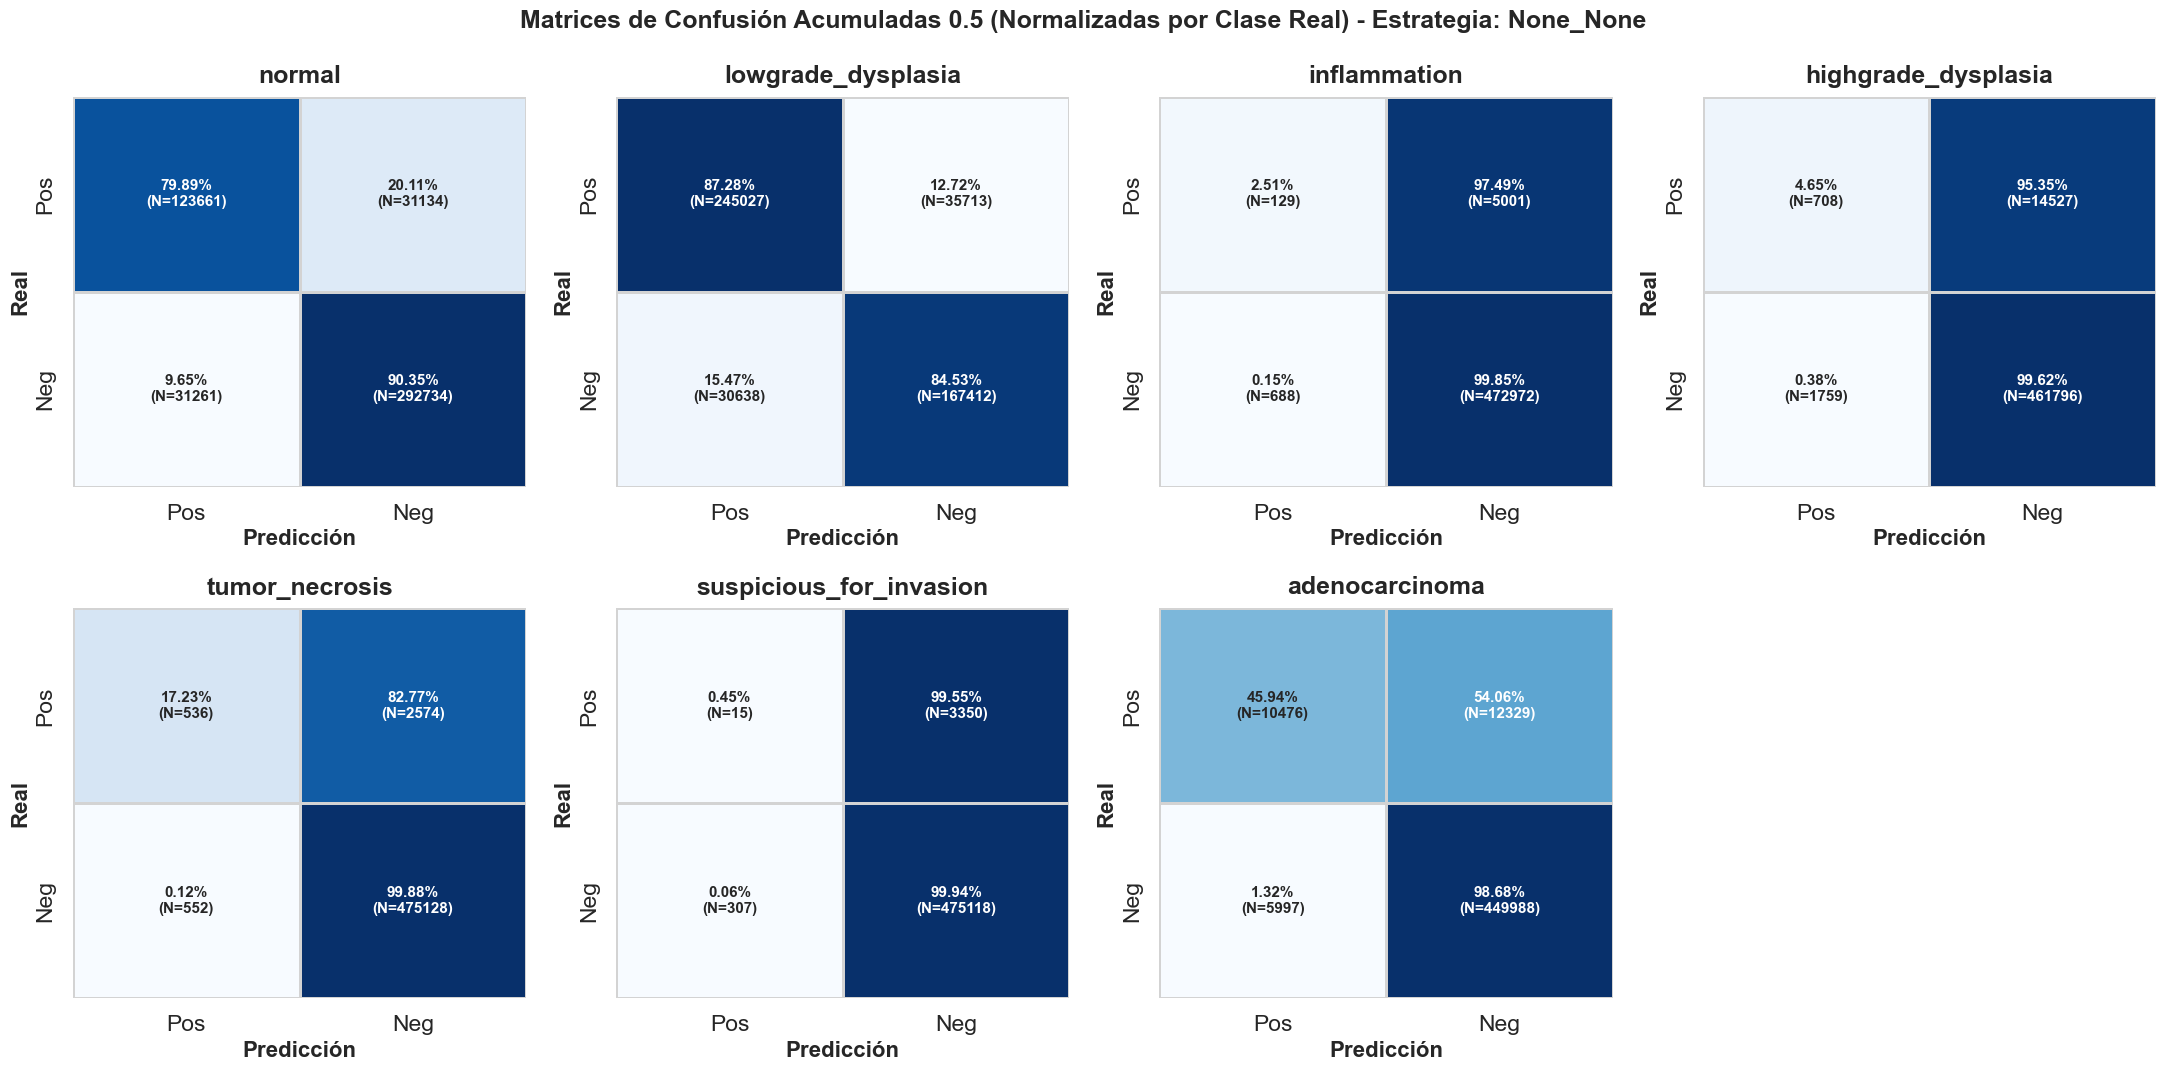

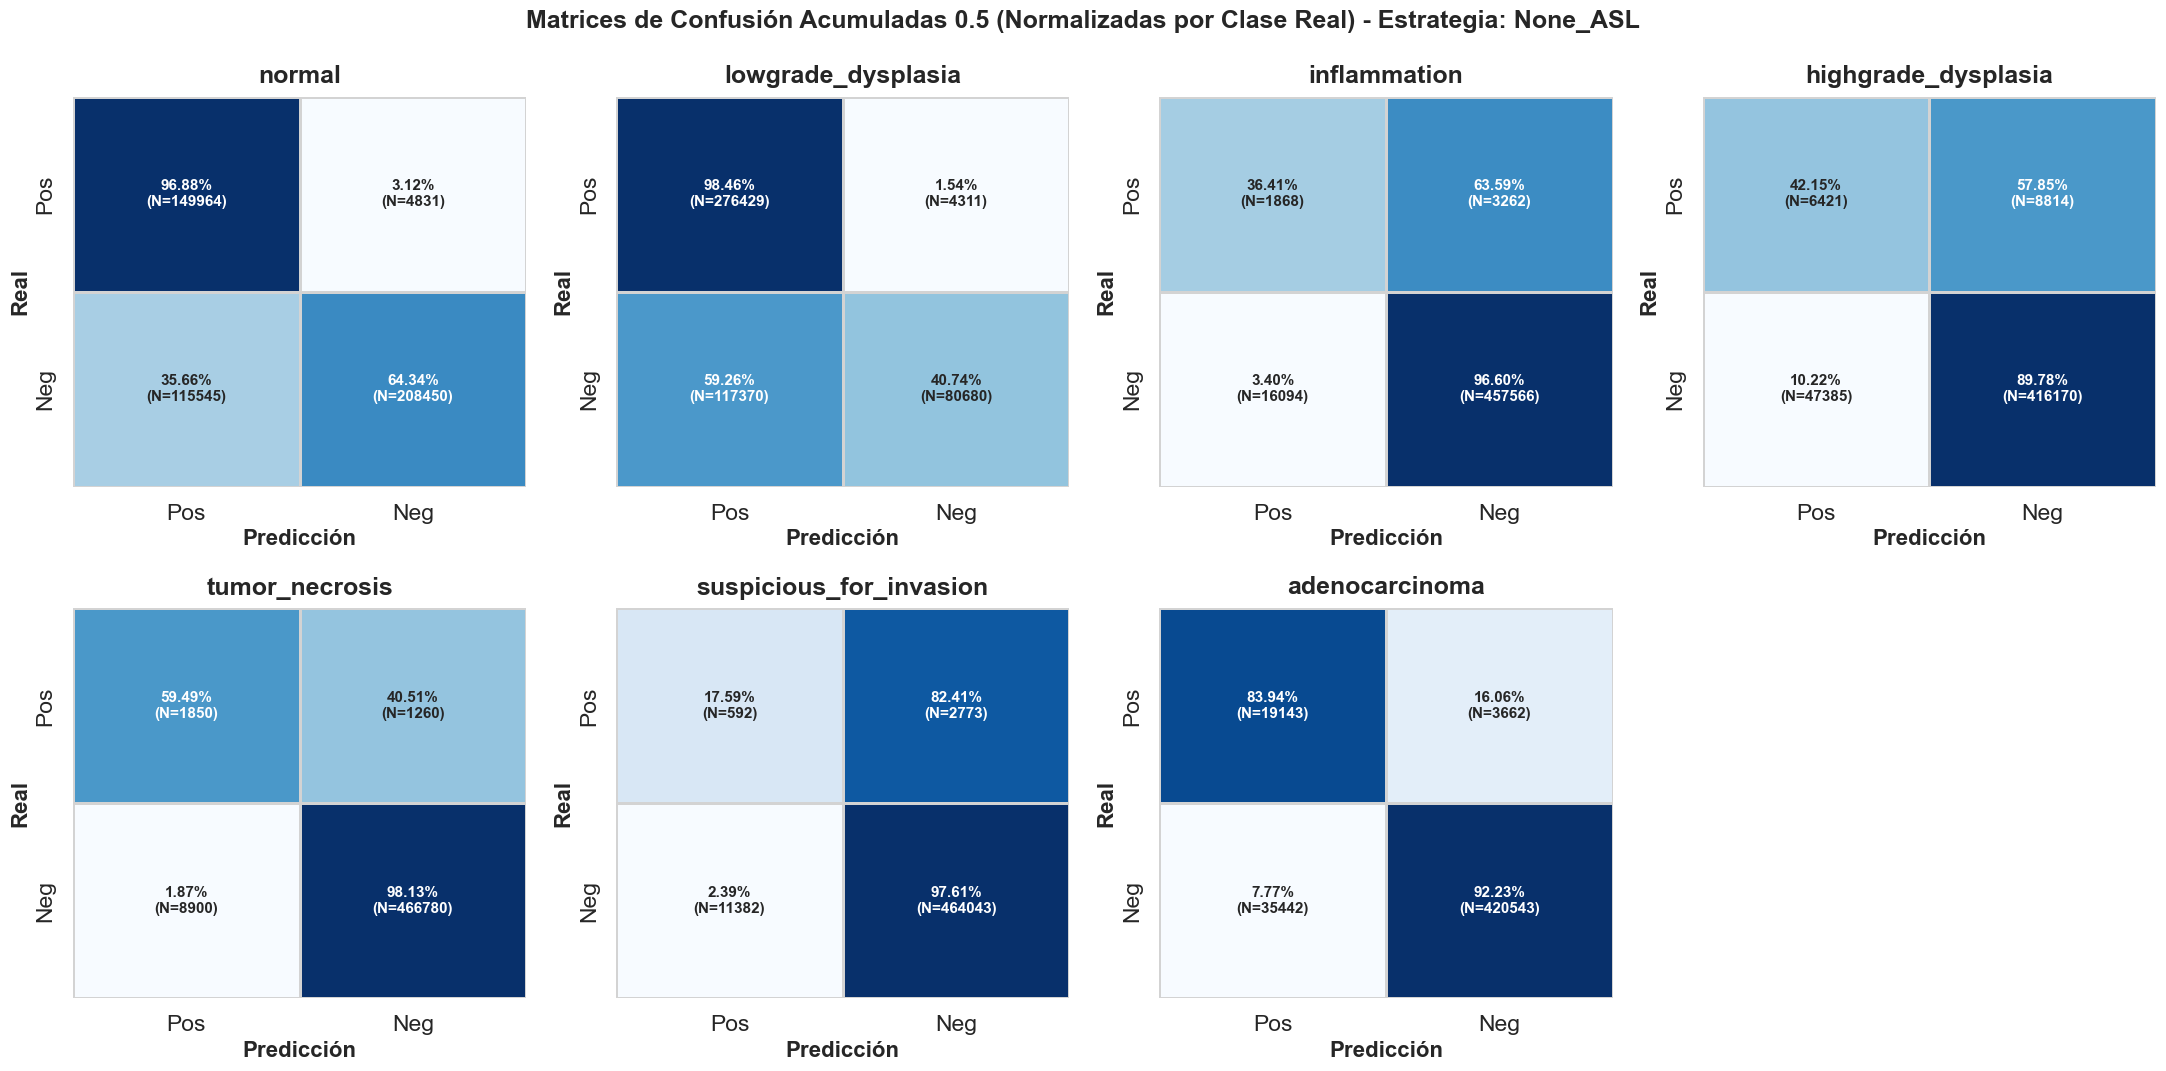

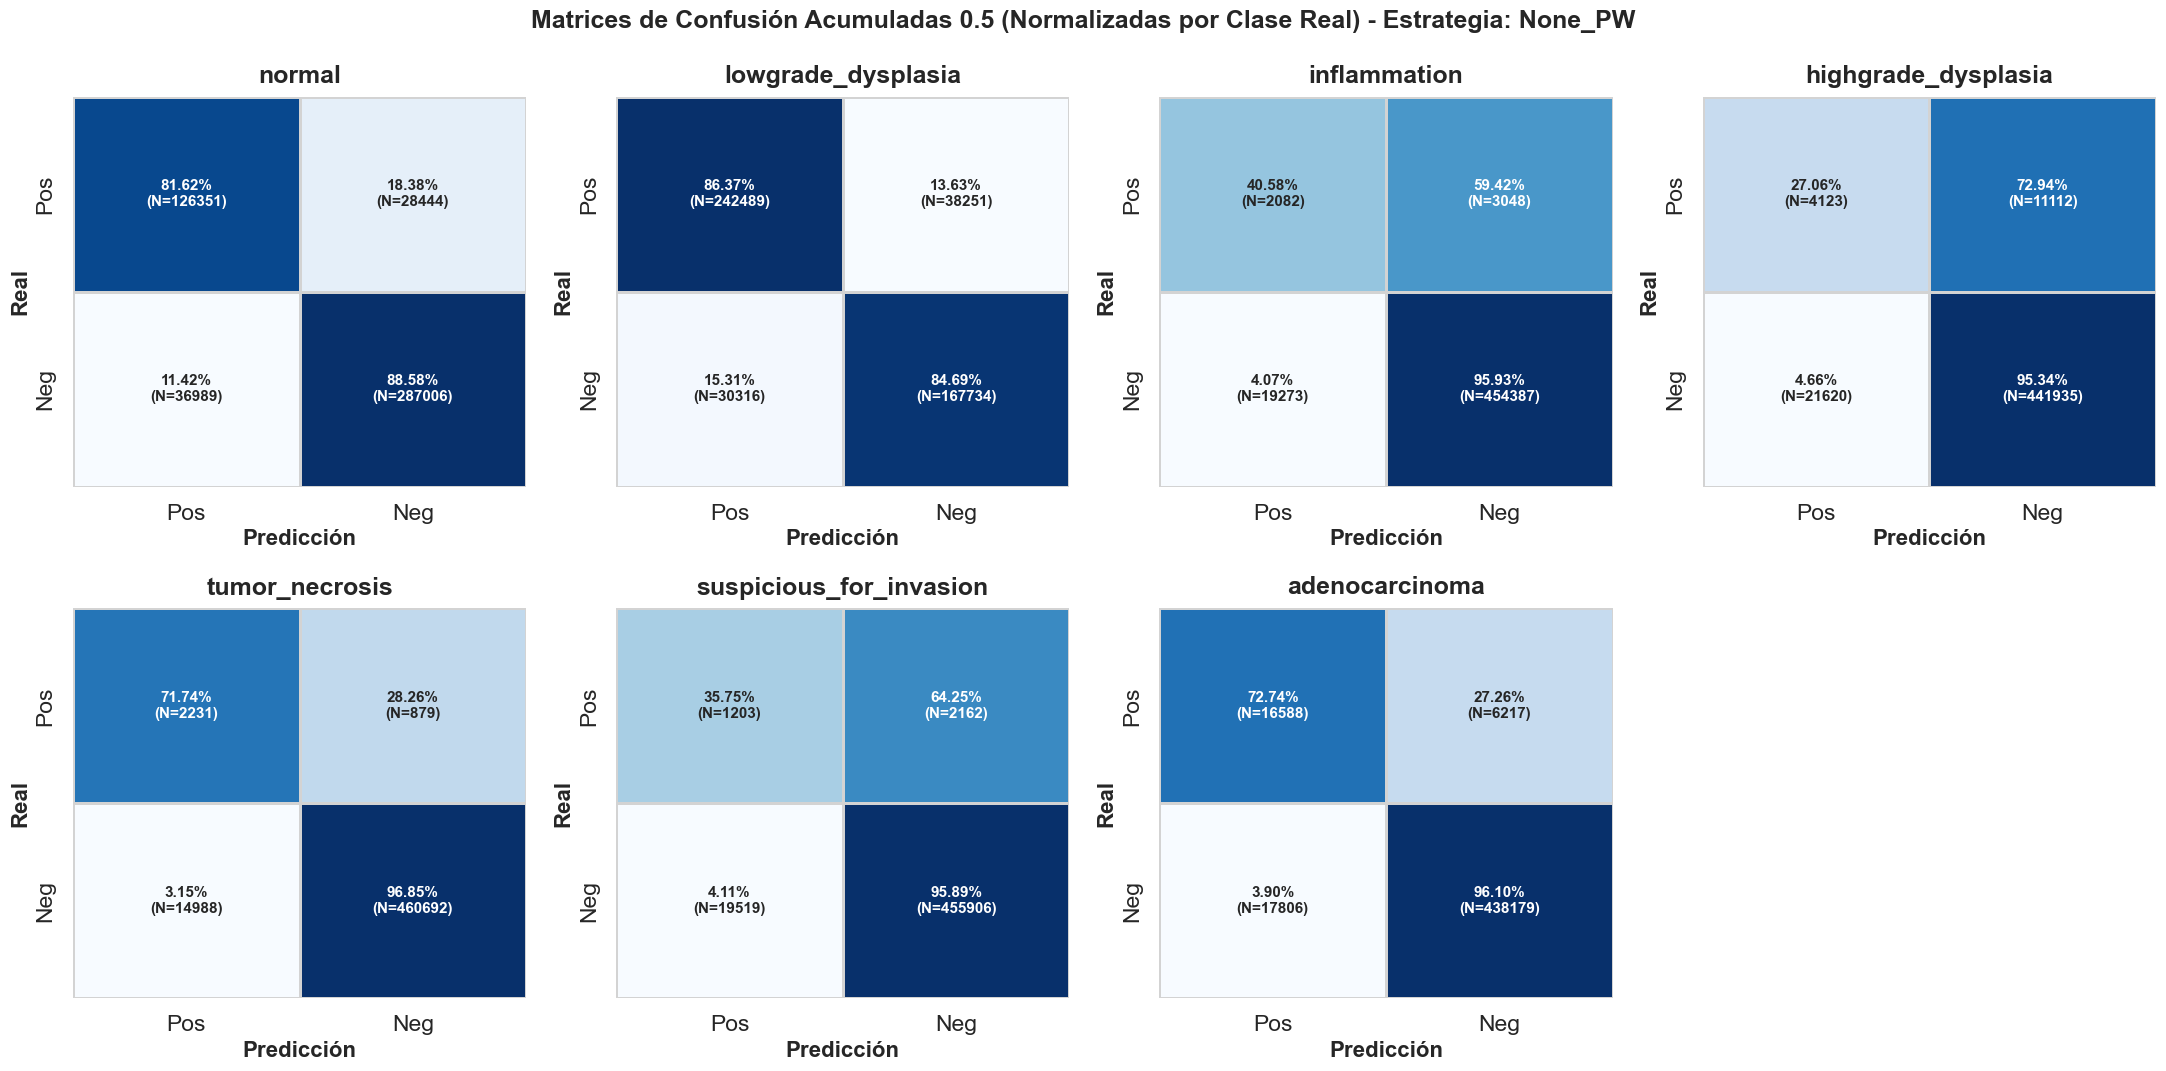

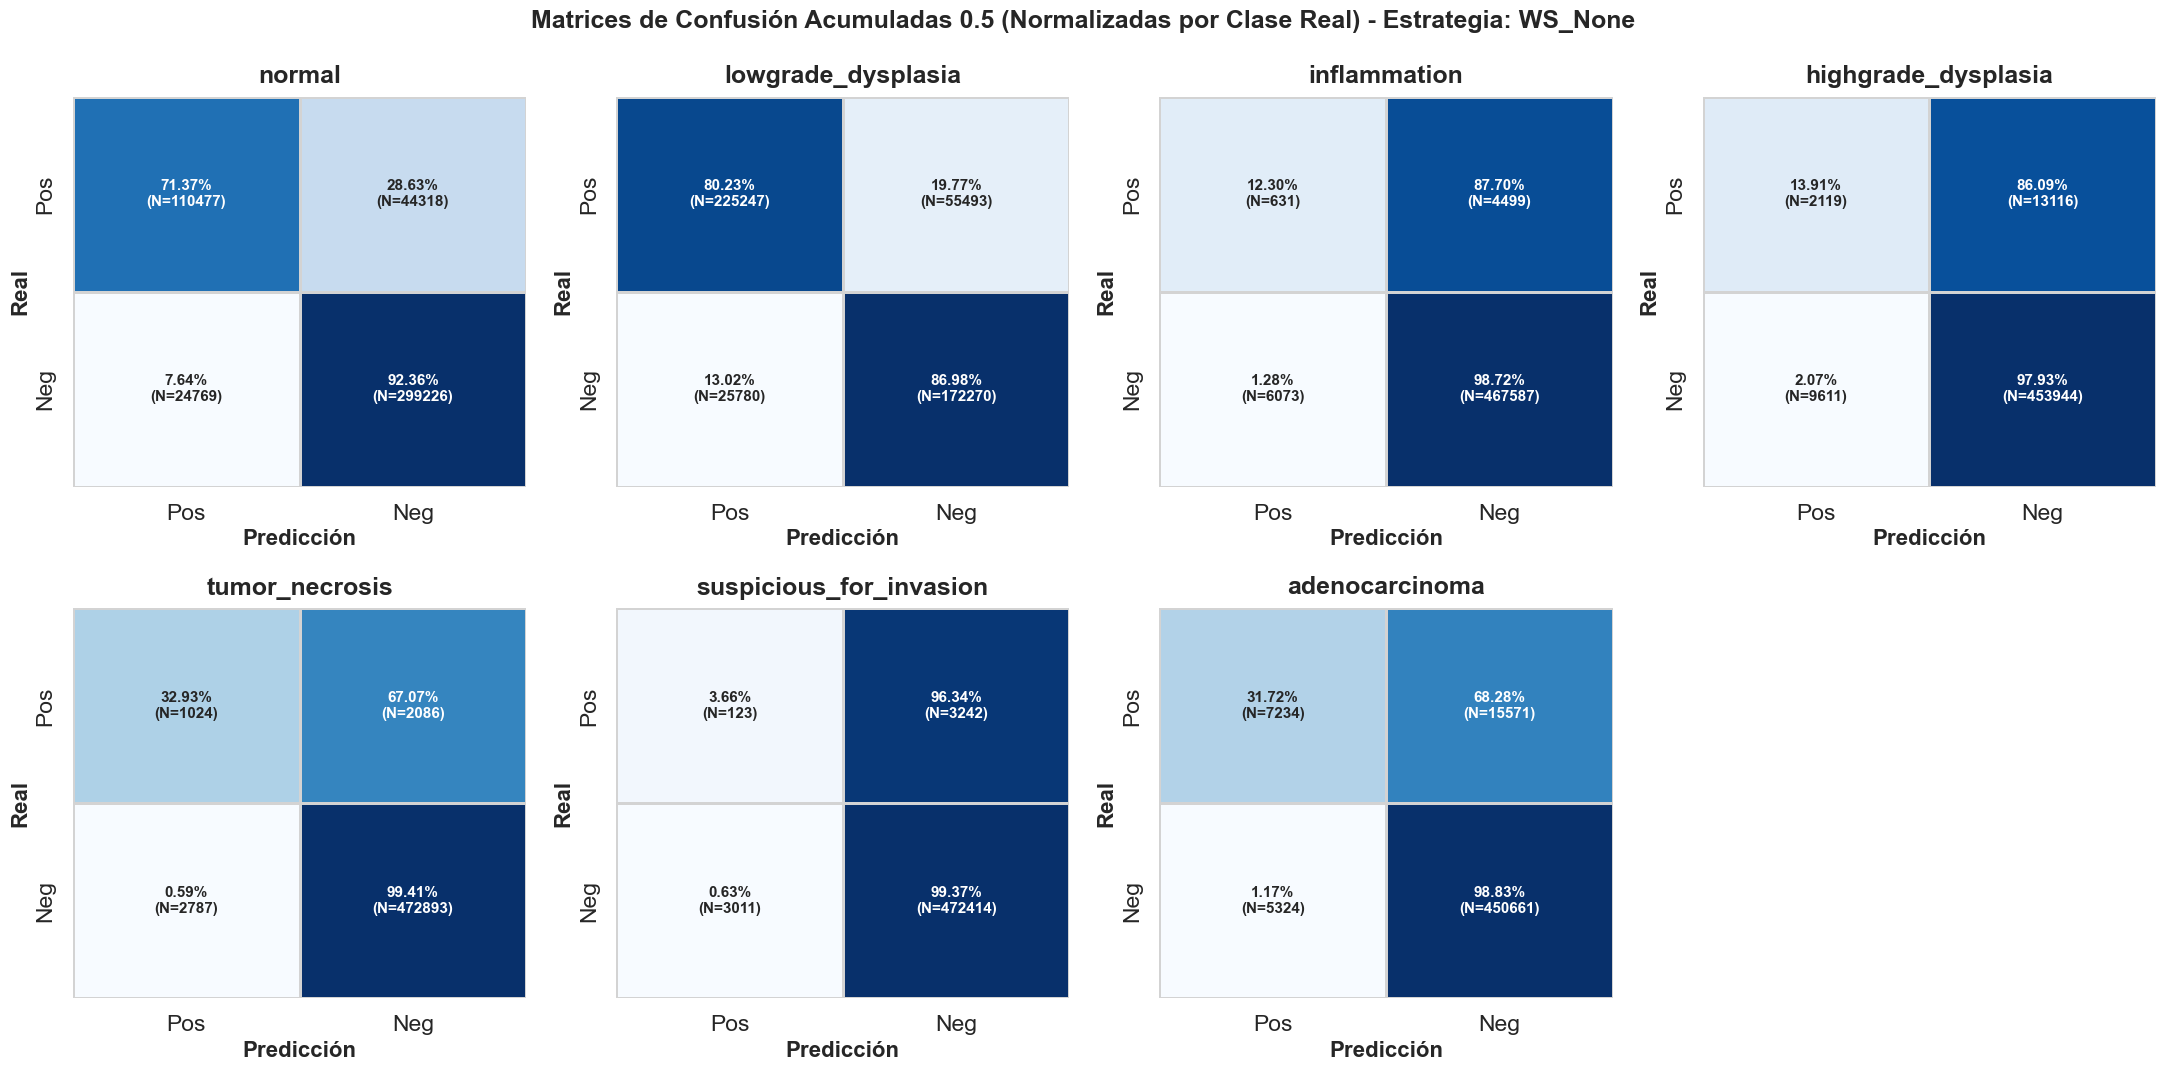

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path 

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
DATA_DIR = ROOT / 'Model_output'

SEEDS = [22, 32, 42, 52, 62]
FOLDS = [1, 2, 3, 4, 5]
ESTRATEGIAS = ["None_None", "None_ASL", "None_PW", "WS_None"]
CLASES = ["normal", "lowgrade_dysplasia", "inflammation", "highgrade_dysplasia", "tumor_necrosis", "suspicious_for_invasion", "adenocarcinoma"]

def cargar_predicciones_del_usuario(seed, fold, estrategia):
    """
    Carga las predicciones desde un archivo CSV para una combinación específica
    de semilla, fold y estrategia.
    
    Retorna un diccionario: 
    {
        "nombre_clase": (y_true_array, y_prob_array),
        ...
    }
    """
    # Construimos el nombre del archivo CSV
    nombre_archivo = f"predictions_seed_{seed}_fold{fold}_{estrategia}_test.csv"
    ruta_completa = os.path.join(DATA_DIR, nombre_archivo)
    
    # Control de seguridad si falta alguna partición
    if not os.path.exists(ruta_completa):
        print(f" Archivo CSV no encontrado: {nombre_archivo}")
        return None
        
    # Lectura del archivo CSV con pandas
    df = pd.read_csv(ruta_completa)
    
    resultado = {}
    
    for clase in CLASES:
        col_true = f"{clase}_true"   # Nombre de la columna con los 0s y 1s reales
        col_prob = f"{clase}_prob"   # Nombre de la columna con las probabilidades continuas
        
        # Verificamos si ambas columnas existen en el CSV para esa clase
        if col_true in df.columns and col_prob in df.columns:
            resultado[clase] = (
                df[col_true].to_numpy(),
                df[col_prob].to_numpy()
            )
        else:
            print(f" Columnas '{col_true}' o '{col_prob}' no encontradas en {nombre_archivo}")
            
    # Retorna el diccionario estructurado si logró mapear clases
    return resultado if resultado else None
    pass



# =====================================================================
# BUCLE PRINCIPAL DE ACUMULACIÓN (TP, TN, FP, FN)
# =====================================================================

acumulado = {est: {clase: {"TN": 0, "FP": 0, "FN": 0, "TP": 0} for clase in CLASES} for est in ESTRATEGIAS}


for seed in SEEDS:
    for fold in FOLDS:
        for est in ESTRATEGIAS:
            
            # Cargar las predicciones continuas del fold actual
            preds = cargar_predicciones_del_usuario(seed, fold, est)
            if preds is None:
                continue # Saltarse el modelo si no encuentra el archivo
                
            for clase in CLASES:
                if clase not in preds:
                    continue
                
                y_true, y_prob = preds[clase]
                
                # Binarizar las probabilidades usando el umbral extraído
                y_pred = (y_prob >= 0.5).astype(int)
                
                # Calcular la matriz de confusión asegurando estructura 2x2 mediante 'labels'
                cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel()
                
                # Acumular los totales
                acumulado[est][clase]["TN"] += tn
                acumulado[est][clase]["FP"] += fp
                acumulado[est][clase]["FN"] += fn
                acumulado[est][clase]["TP"] += tp

print(" Conteo acumulado finalizado con éxito.")


sns.set_theme(style="white", context="talk")

for est in ESTRATEGIAS:
    # Creamos una cuadrícula de 2x4
    fig, axes = plt.subplots(2, 4, figsize=(22, 11))
    axes_flat = axes.flatten()
    
    for i, clase in enumerate(CLASES):
        ax = axes_flat[i]
        
        # Recuperamos los datos acumulados totales (suma de los 25 modelos)
        tn = acumulado[est][clase]["TN"]
        fp = acumulado[est][clase]["FP"]
        fn = acumulado[est][clase]["FN"]
        tp = acumulado[est][clase]["TP"]
        
        # --- NUEVA LÓGICA DE PORCENTAJES POR FILA (REALES) ---
        total_negativos_reales = tn + fp
        total_positivos_reales = fn + tp
        
        # Calculamos porcentajes independientes por fila controlando división por cero
        tn_pct = (tn / total_negativos_reales) * 100 if total_negativos_reales > 0 else 0.0
        fp_pct = (fp / total_negativos_reales) * 100 if total_negativos_reales > 0 else 0.0
        
        fn_pct = (fn / total_positivos_reales) * 100 if total_positivos_reales > 0 else 0.0
        tp_pct = (tp / total_positivos_reales) * 100 if total_positivos_reales > 0 else 0.0
        
        # Matriz de porcentajes para el código de colores del heatmap
        porcentajes = np.array([
            [tp_pct, fn_pct],
            [fp_pct, tn_pct]
        ])
        
        # Formatear el texto tal y como pediste: Porcentaje + \n + (N= conteo)
        labels_texto = np.array([
            [f"{tp_pct:.2f}%\n(N={tp})", f"{fn_pct:.2f}%\n(N={fn})"],
            [f"{fp_pct:.2f}%\n(N={fp})", f"{tn_pct:.2f}%\n(N={tn})"]
        ])
        
        # Dibujar heatmap
        sns.heatmap(
            porcentajes,         
            annot=labels_texto,  
            fmt="",              
            cmap="Blues",        
            cbar=False,          
            ax=ax,
            xticklabels=["Pos", "Neg"],
            yticklabels=["Pos", "Neg"],
            annot_kws={"size": 11, "weight": "bold"},
            linewidths=1,
            linecolor="lightgray"
        )
        
        ax.set_xlabel("Predicción", weight='bold', size=16, labelpad=4)
        ax.set_ylabel("Real", weight='bold', size=16, labelpad=4)
        
        ax.set_title(f"{clase}", weight='bold', size=18, pad=10)
        
    # Ocultar por completo el cuadrante 8 sobrante para mantener simetría estética
    axes_flat[7].axis('off')
    
    # Ajustes de títulos generales
    plt.suptitle(f"Matrices de Confusión Acumuladas 0.5 (Normalizadas por Clase Real) - Estrategia: {est}", weight='bold', size=18, y=0.98)
    plt.tight_layout()
    
    # Guardar gráfica de forma independiente
    plt.savefig(ROOT / 'plots_interesantes' / f"confusion_matrix_acumulada_0.5_{est}.png", dpi=300, bbox_inches='tight')
    plt.show()

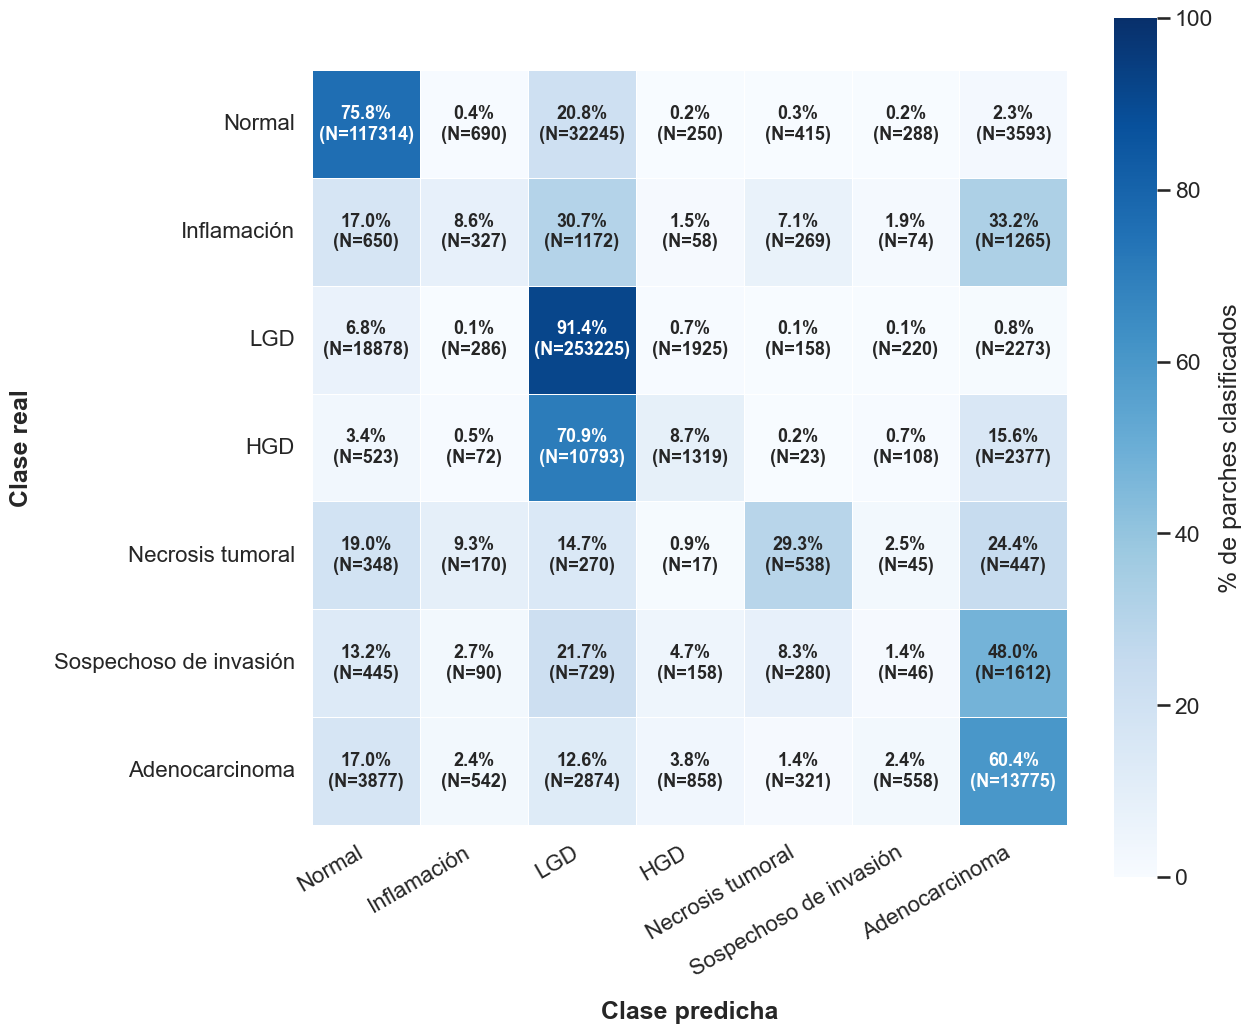

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path 

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
DATA_DIR = ROOT / 'Model_output_hierarchical'

SEEDS = [22, 32, 42, 52, 62]
FOLDS = [1, 2, 3, 4, 5]

TAMANO_TEXTO_CELDAS = 13 


CLASES = ["normal", "inflammation", "lowgrade_dysplasia", "highgrade_dysplasia", "tumor_necrosis", "suspicious_for_invasion", "adenocarcinoma"]

CLASES_ESPANOL = [
    "Normal", 
    "Inflamación", 
    "LGD", 
    "HGD", 
    "Necrosis tumoral", 
    "Sospechoso de invasión", 
    "Adenocarcinoma"
]

acumulado_mc = np.zeros((len(CLASES), len(CLASES)), dtype=np.int64)

for seed in SEEDS:
    for fold in FOLDS:
        nombre_archivo = (
            f"predictions_hierarchical_seed_{seed}_fold_{fold}_test.csv"
        )

        ruta = DATA_DIR / nombre_archivo

        if not ruta.exists():
            print(f" No encontrado: {nombre_archivo}")
            continue

        df = pd.read_csv(ruta)

        y_true = df["true_label"].values
        y_pred = df["pred_label"].values

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=np.arange(len(CLASES))
        )

        acumulado_mc += cm
            
cm = acumulado_mc

cm_pct = (
    cm.astype(float)
    / cm.sum(axis=1, keepdims=True)
) * 100

annot = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = (
            f"{cm_pct[i,j]:.1f}%\n"
            f"(N={cm[i,j]})"
        )

# Configuramos el estilo visual limpio
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(13, 11))

sns.heatmap(
    cm_pct,
    annot=annot,
    fmt="",
    cmap="Blues",
    xticklabels=CLASES_ESPANOL,
    yticklabels=CLASES_ESPANOL,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "% de parches clasificados"},
    vmin=0, vmax=100,
    annot_kws={"size": TAMANO_TEXTO_CELDAS, "weight": "semibold"} 
)

# Títulos de los ejes formales
plt.xlabel("Clase predicha", fontsize=18, fontweight="bold", labelpad=15)
plt.ylabel("Clase real", fontsize=18, fontweight="bold", labelpad=15)


plt.xticks(rotation=30, ha="right", fontsize=16)
plt.yticks(rotation=0, fontsize=16)

plt.tight_layout()

# Asegurar que existe la carpeta de guardado
(ROOT / "plots_interesantes").mkdir(parents=True, exist_ok=True)

plt.savefig(
    ROOT / "plots_interesantes" / "confusion_matrix_multiclase.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

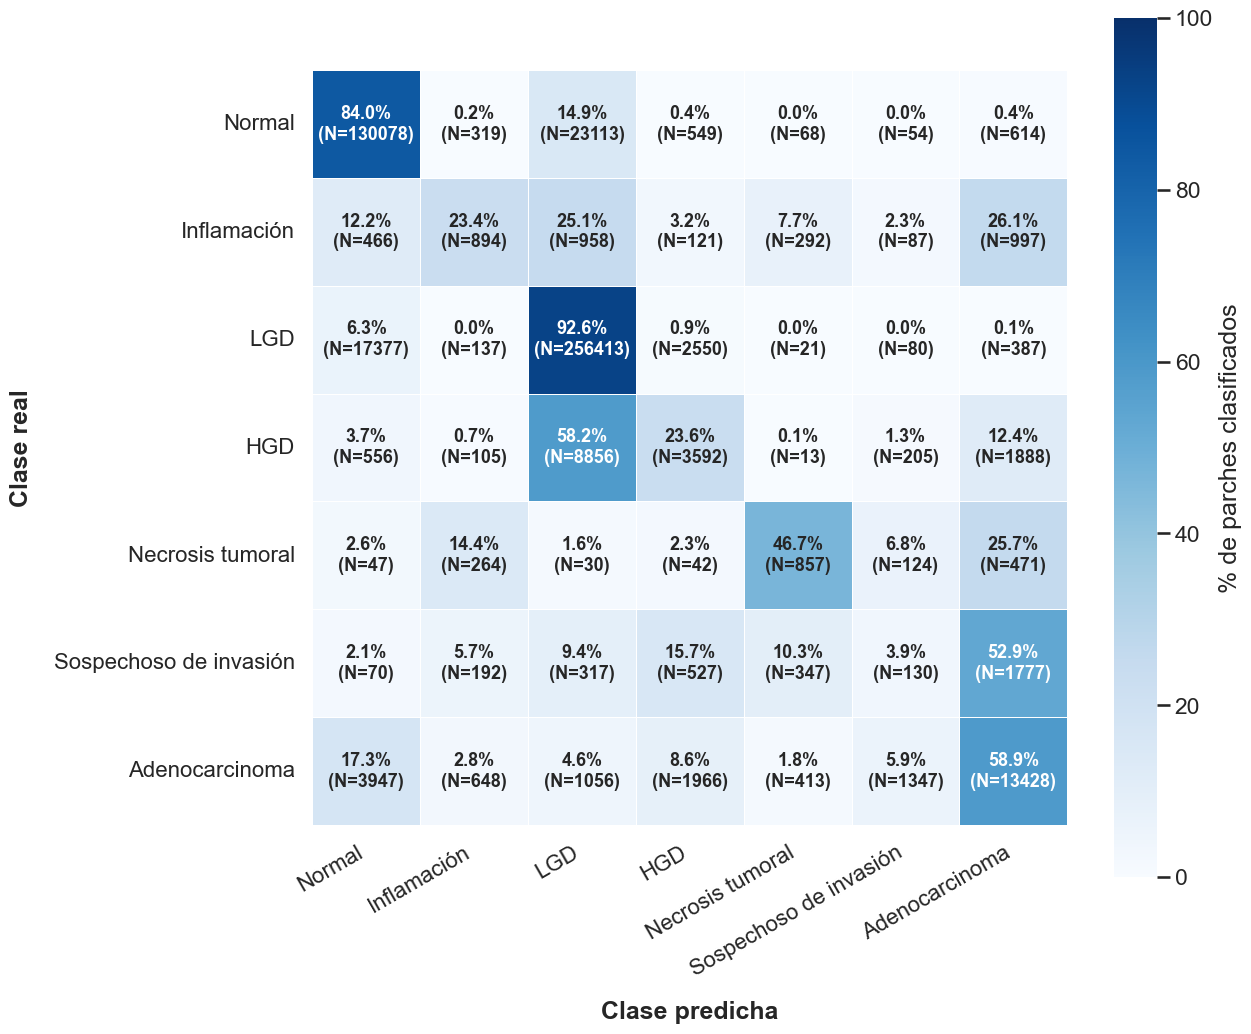

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path 

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
DATA_DIR = ROOT / 'UNI_output_hierarchical'

SEEDS = [22, 32, 42, 52, 62]
FOLDS = [1, 2, 3, 4, 5]


TAMANO_TEXTO_CELDAS = 13

CLASES = ["normal", "inflammation", "lowgrade_dysplasia", "highgrade_dysplasia", "tumor_necrosis", "suspicious_for_invasion", "adenocarcinoma"]

CLASES_ESPANOL = [
    "Normal", 
    "Inflamación", 
    "LGD", 
    "HGD", 
    "Necrosis tumoral", 
    "Sospechoso de invasión", 
    "Adenocarcinoma"
]

acumulado_mc = np.zeros((len(CLASES), len(CLASES)), dtype=np.int64)

for seed in SEEDS:
    for fold in FOLDS:
        nombre_archivo = (
            f"predictions_hierarchical_seed_{seed}_fold_{fold}_test.csv"
        )

        ruta = DATA_DIR / nombre_archivo

        if not ruta.exists():
            print(f" No encontrado: {nombre_archivo}")
            continue

        df = pd.read_csv(ruta)

        y_true = df["true_label"].values
        y_pred = df["pred_label"].values

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=np.arange(len(CLASES))
        )

        acumulado_mc += cm
            
cm = acumulado_mc

cm_pct = (
    cm.astype(float)
    / cm.sum(axis=1, keepdims=True)
) * 100

annot = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = (
            f"{cm_pct[i,j]:.1f}%\n"
            f"(N={cm[i,j]})"
        )

# Configuramos el estilo visual limpio
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(13, 11))

sns.heatmap(
    cm_pct,
    annot=annot,
    fmt="",
    cmap="Blues",
    xticklabels=CLASES_ESPANOL,
    yticklabels=CLASES_ESPANOL,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "% de parches clasificados"},
    vmin=0, vmax=100,
    annot_kws={"size": TAMANO_TEXTO_CELDAS, "weight": "semibold"} 
)

# Títulos de los ejes formales
plt.xlabel("Clase predicha", fontsize=18, fontweight="bold", labelpad=15)
plt.ylabel("Clase real", fontsize=18, fontweight="bold", labelpad=15)


plt.xticks(rotation=30, ha="right", fontsize=16)
plt.yticks(rotation=0, fontsize=16)

plt.tight_layout()

# Asegurar que existe la carpeta de guardado
(ROOT / "plots_interesantes").mkdir(parents=True, exist_ok=True)

plt.savefig(
    ROOT / "plots_interesantes" / "confusion_matrix_UNI.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
import json
import pandas as pd
from pathlib import Path 

ruta_json = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Metrics_hierarchical_UNI\global_report_hierarchical.json')

with open(ruta_json, 'r', encoding='utf-8') as f:
    data = json.load(f)

global_metrics = data["global_metrics"]

elementos_a_incluir = [
    'normal',
    'inflammation',
    'lowgrade_dysplasia',
    'highgrade_dysplasia',
    'tumor_necrosis',
    'suspicious_for_invasion',
    'adenocarcinoma',
    "macro avg"
]

lista_tabla = []


for elemento in elementos_a_incluir:
    if elemento in global_metrics:
        f1_data = global_metrics[elemento]["f1-score"]
        mean_val = f1_data["mean"]
        std_val = f1_data["std"]
        
        # Formatear el nombre para que se vea más limpio en la tabla
        nombre_formateado = elemento.replace("_", " ").title() if elemento != "macro avg" else "Macro Avg"
        
        # Guardar en la lista con el formato "media ± std" redondeado a 4 decimales
        lista_tabla.append({
            "Clase / Métrica": nombre_formateado,
            "F1-Score (Mean ± STD)": f"{mean_val:.4f} ± {std_val:.4f}"
        })

# Crear el DataFrame e imprimir la tabla
df_f1 = pd.DataFrame(lista_tabla)

print("\n REPORTE DE F1-SCORE GLOBAL:")
print("=" * 45)
print(df_f1.to_string(index=False))
print("=" * 45)


📊 REPORTE DE F1-SCORE GLOBAL:
        Clase / Métrica F1-Score (Mean ± STD)
                 Normal       0.8444 ± 0.0377
           Inflammation       0.2626 ± 0.1087
     Lowgrade Dysplasia       0.9001 ± 0.0279
    Highgrade Dysplasia       0.2758 ± 0.1379
         Tumor Necrosis       0.3836 ± 0.1933
Suspicious For Invasion       0.0440 ± 0.0405
         Adenocarcinoma       0.6359 ± 0.0686
              Macro Avg       0.4781 ± 0.0467


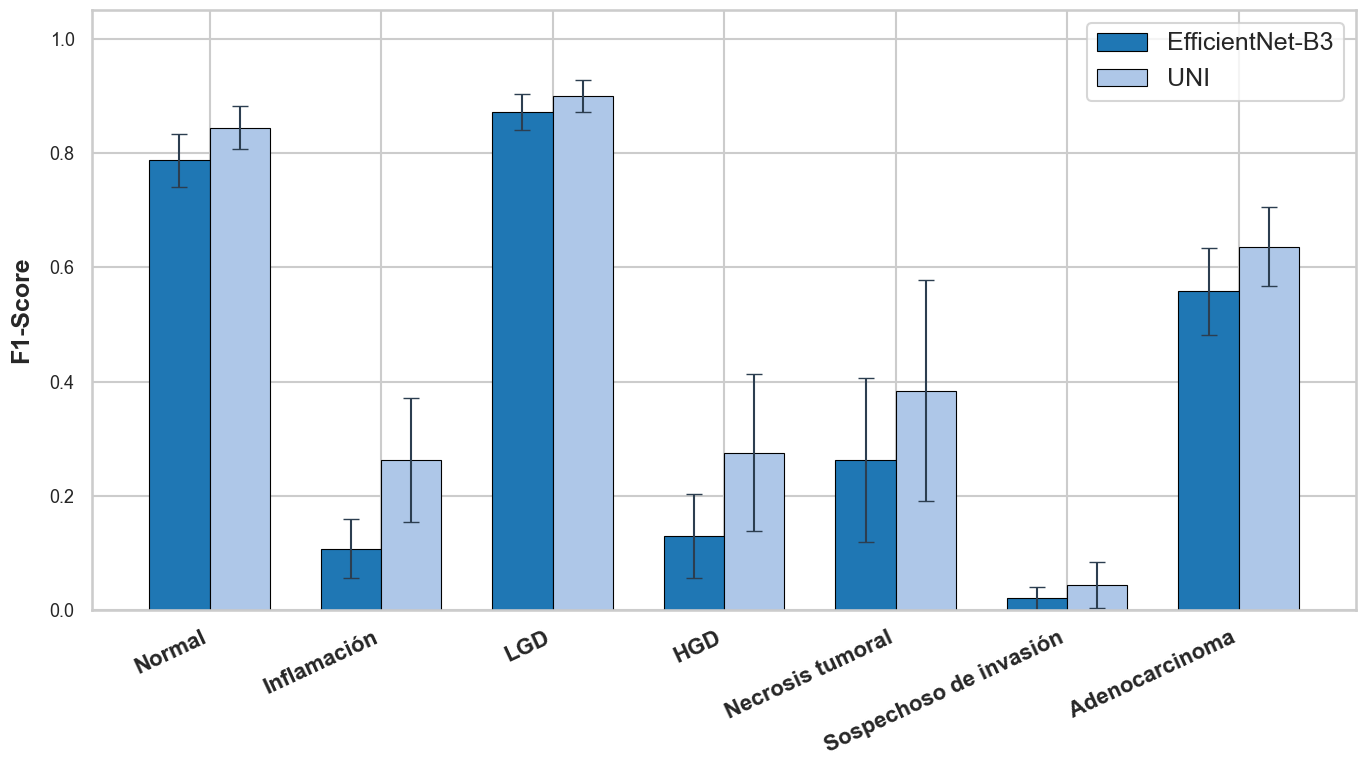

¡Gráfico comparativo con incertidumbre guardado con éxito en: C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\plots_interesantes\comparativa_f1_modelos.png!


In [ ]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')


PATH_REPORTE_1 = ROOT / 'Metrics_hierarchical' / 'global_report_hierarchical.json'
PATH_REPORTE_2 = ROOT / 'Metrics_hierarchical_UNI' / 'global_report_hierarchical.json' 


LABEL_MODELO_1 = "EfficientNet-B3"
LABEL_MODELO_2 = "UNI"


CLASSES = [
    'normal', 
    'inflammation', 
    'lowgrade_dysplasia', 
    'highgrade_dysplasia',
    'tumor_necrosis', 
    'suspicious_for_invasion', 
    'adenocarcinoma'
]


CLASES_ESPANOL = [
    "Normal", 
    "Inflamación", 
    "LGD", 
    "HGD", 
    "Necrosis tumoral", 
    "Sospechoso de invasión", 
    "Adenocarcinoma"
]

def extraer_f1_metricas(ruta_json):
    means = []
    stds = []
    
    if not ruta_json.exists():
        print(f" Error: No se encontró el archivo en {ruta_json}")
        return None, None
        
    with open(ruta_json, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    for clase in CLASSES:
        # Extraer media e incertidumbre (std) del f1-score
        try:
            f1_mean = data["global_metrics"][clase]["f1-score"]["mean"]
            f1_std = data["global_metrics"][clase]["f1-score"]["std"]
        except KeyError:
            print(f" Alerta: No se encontró F1-score para '{clase}' en {ruta_json.name}. Usando 0.")
            f1_mean, f1_std = 0.0, 0.0
            
        means.append(f1_mean)
        stds.append(f1_std)
        
    return np.array(means), np.array(stds)

means_1, stds_1 = extraer_f1_metricas(PATH_REPORTE_1)
means_2, stds_2 = extraer_f1_metricas(PATH_REPORTE_2)

if means_1 is not None and means_2 is not None:
    
    sns.set_theme(style="whitegrid", context="talk")
    
    x = np.arange(len(CLASES_ESPANOL))  # Localización de las etiquetas de las clases
    width = 0.35  # Ancho de cada barra individual
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Dibujar Barras del Modelo 1 (con su barra de error / incertidumbre)
    rects1 = ax.bar(
        x - width/2, 
        means_1, 
        width, 
        yerr=stds_1, 
        label=LABEL_MODELO_1,
        capsize=6,             
        color="#1f77b4",       
        edgecolor="black", 
        linewidth=0.8,
        error_kw={"ecolor": "#2c3e50", "lw": 1.5} 
    )
    
    # Dibujar Barras del Modelo 2 (con su barra de error / incertidumbre)
    rects2 = ax.bar(
        x + width/2, 
        means_2, 
        width, 
        yerr=stds_2, 
        label=LABEL_MODELO_2,
        capsize=6, 
        color="#aec7e8",       
        edgecolor="black", 
        linewidth=0.8,
        error_kw={"ecolor": "#2c3e50", "lw": 1.5}
    )
    
    # Ajustes de etiquetas y formato académico
    ax.set_ylabel("F1-Score", fontsize=18, fontweight="bold", labelpad=12)
    
    ax.set_xticks(x)
    ax.set_xticklabels(CLASES_ESPANOL, rotation=25, ha="right", fontsize=16, fontweight="semibold")
    
    # Forzar el rango del eje Y entre 0 y 1 (ya que el F1 máximo es 1.0)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='y', labelsize=13)
    
    # Leyenda formal
    ax.legend(loc="upper right", fontsize=18, frameon=True, shadow=False)
    
    plt.tight_layout()
    
    # Guardar gráfico en alta resolución
    (ROOT / "plots_interesantes").mkdir(parents=True, exist_ok=True)
    ruta_salida = ROOT / "plots_interesantes" / "comparativa_f1_modelos.png"
    plt.savefig(ruta_salida, dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"¡Gráfico comparativo con incertidumbre guardado con éxito en: {ruta_salida}!")